# Batch-corrected WGCNA notebook

PyWGCNA analysis for the primary Jena RNA-seq dataset (**GEO GSE334185**).

This notebook uses the batch-corrected WGCNA input files generated by `02_jena_wgcna_preprocessing.R`. Outputs are written to a separate `Jena_count_DEseq2_batchCorrected_nonzero_50mod_0.4thresh_robustZ_diffNames` folder so the original WGCNA run is not overwritten.

Expected input files in the WGCNA working directory:
- `Jena_RNAseq_DEseq2norm_batchCorrected_diffNames_vstTyler_q75.csv`
- `Jena_metadata_modified2_batch.csv`

Set the `JENA_WGCNA_DIR` environment variable to the directory containing these inputs, or launch the notebook from that directory. The statistical analysis and stored notebook outputs are otherwise unchanged.


In [1]:
%matplotlib inline
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns; sns.set()
import math
from pylab import *
import re
import random
from sklearn.decomposition import PCA
# Using Skicit-learn to split data into training and testing sets
from sklearn.model_selection import train_test_split
# Import the model we are using
from sklearn.ensemble import RandomForestRegressor
# Import tools needed for visualization
from sklearn.tree import export_graphviz
from sklearn.preprocessing import StandardScaler
import pydot
# from yellowbrick.datasets import load_concrete
# from yellowbrick.regressor import ResidualsPlot
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from datetime import date
import anndata as ad
import PyWGCNA
# import rpy2.robjects as ro
# from rpy2.robjects import pandas2ri
# pandas2ri.activate()
# import requests
from pybiomart import Dataset
import mygene
from scipy.stats import norm
from statsmodels.distributions.empirical_distribution import ECDF
import gseapy as gp
from gseapy.plot import dotplot
from reactome2py import analysis, content
import os
import time
import pydot
import pyarrow
import pyarrow.feather as feather
print(pyarrow.__version__)
# Portable working-directory configuration.
# Set JENA_WGCNA_DIR, or run the notebook from the directory containing the WGCNA inputs.
base_dir = os.environ.get("JENA_WGCNA_DIR", os.getcwd())
if not os.path.isdir(base_dir):
    raise FileNotFoundError(f"JENA_WGCNA_DIR does not exist: {base_dir}")
os.chdir(base_dir)
print(f"WGCNA working directory: {base_dir}")


23.0.0


In [2]:
def robust_zscore(df, distribution='nonnorm', tail='upper'):
    ### Parameters:
    # df - input dataframe of genes with a column named 'connectivity' which contains the connectivity values
    # distribution (default = 'nonnorm') - Whether the p-value of a z-score should be compared to a normal distribution or non-normal
    # tail (default = 'upper') - Whether to calculate p-values taking into consideration both upper and lower tails, or a specific one. Default is upper since it is being used for identifying key hub genes, which should be the most connected.
    def calc_robust_zscore(x):
        median_x = np.nanmedian(x)
        mad_x = np.nanmedian(np.abs(x - median_x))  # MAD calculation
        return 0.6745 * (x - median_x) / mad_x  # 0.6745 to make MAD consistent with the standard deviation for normally distributed data
    
    def calc_pvalue(z):
        return 2 * norm.cdf(-np.abs(z))
    
    def calc_empirical_pvalue(values, tail):
        """
        Calculate the empirical p-values for each value in the 'connectivity' column using ECDF.
        """
        ecdf = ECDF(values)
        if tail == 'both':
            p_values = values.apply(lambda z: 2 * min(ecdf(z), 1 - ecdf(z)))
        elif tail == 'upper':
            p_values = values.apply(lambda z: 1 - ecdf(z))
        elif tail == 'lower':
            p_values = values.apply(lambda z: ecdf(z))
        return p_values

    if not isinstance(df, pd.DataFrame):
        raise ValueError("Input must be a DataFrame")

    result = calc_robust_zscore(df['connectivity'])#df['connectivity'].apply(calc_robust_zscore)
    result.index = df.index  # Preserve row names if they exist
    result = result.rename('connectivity_zscore')
    if distribution == 'nonnorm':
        result_pval = calc_empirical_pvalue(df['connectivity'], tail)#[calc_empirical_pvalue(z, df['connectivity']) for z in df['connectivity']]#result.apply(calc_pvalue)
    elif distribution == 'norm':
        result_pval = result.apply(calc_pvalue)
    result_pval.index = df.index  # Preserve row names if they exist
    result_pval = result_pval.rename('p-val')
    result_out = pd.concat([result, result_pval], axis=1)

    return result_out

def calculate_overlap(col1, col2, case_sensitive=False):
    if not case_sensitive:
        col1 = col1.str.lower()
        col2 = col2.str.lower()

    unique1 = pd.Series(col1.dropna().unique())
    unique2 = pd.Series(col2.dropna().unique())
    
    intersection = pd.Series(np.intersect1d(unique1, unique2))

    overlap_percentage = len(intersection) / len(pd.Series(np.union1d(unique1, unique2))) * 100

    return overlap_percentage

In [3]:
### PyWGCNA Quick Start Guide: https://github.com/mortazavilab/PyWGCNA/blob/main/tutorials/Quick_Start.ipynb

today = date.today()

# def shinygo_enrichment(species_code, gene_list, gene_set='GO_Biological_Process'):
#     url = 'http://bioinformatics.sdstate.edu/go/'
#     headers = {'Content-Type': 'application/json'}
#     payload = {
#         'species': species_code,
#         'genes': ','.join(gene_list),
#         'gene_set': gene_set
#     }

#     response = requests.post(url, json=payload, headers=headers)
#     response = requests.get(url, params=payload, headers=headers)

#     if response.status_code == 200:
#         result = response.json()
#         return result
#     else:
#         print(f'Error {response.status_code}: {response.text}')
#         return None

def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->',
                    linewidth=2,
                    shrinkA=0, shrinkB=0)
    ax.annotate('', v1, v0, arrowprops=arrowprops)
    
def first_unique_values(lst):
    seen = set()
    unique = []
    for item in lst:
        if item not in seen:
            unique.append(item)
            seen.add(item)
    return unique
    
def generate_colors(sample_list):
    """
    Generate colors for each unique prefix in the sample_list, ensuring
    that the same prefixes are assigned the same colors.
    """
    # Extract the prefix before the '-' for each sample, passing numbers without modification
    # sample_prefixes = [sample.split('-')[0] for sample in sample_list]
    sample_prefixes = [sample.split('-')[0] if isinstance(sample, str) else str(sample) for sample in sample_list]
    unique_prefixes = sorted(set(sample_prefixes))  # Ensure a consistent order
    # List of basic single-word colors
    basic_colors = [
    'red', 'blue', 'green', 'yellow', 'orange', 'purple', 'pink', 'brown',
    'gray', 'black', 'white', 'cyan', 'magenta', 'lime', 'maroon', 'navy', 
    'olive', 'teal', 'aqua', 'fuchsia', 'indigo', 'violet', 'turquoise', 'gold',
    'silver', 'beige', 'coral', 'lavender'
    ]
    # Get a list of all named colors in Matplotlib
    basic_colors = first_unique_values(basic_colors + list(matplotlib.colors.CSS4_COLORS.keys()))
    
    if len(unique_prefixes) > len(basic_colors):
        raise ValueError(f"Requested {len(unique_prefixes)} colors, but only {len(basic_colors)} unique basic colors are available.")

    # Create a color map using the basic colors
    prefix_to_color = {prefix: basic_colors[i % len(basic_colors)] for i, prefix in enumerate(unique_prefixes)}
    return [prefix_to_color[prefix] for prefix in sample_prefixes]

# Defining function analygous to R package WGCNA's goodSampleGenes() from chatGPT, if needed. TH 7-12-2024:
def good_samples_genes(df, min_fraction=0.8):
    """
    Check for good samples and genes.
    
    Parameters:
    - df: pandas DataFrame, rows are samples and columns are genes
    - min_fraction: minimum fraction of non-missing entries required
    
    Returns:
    - good_samples: list of good sample indices
    - good_genes: list of good gene indices
    """
    # Calculate the fraction of non-missing entries for each gene (column)
    gene_fraction = df.notna().mean(axis=0)
    
    # Calculate the fraction of non-missing entries for each sample (row)
    sample_fraction = df.notna().mean(axis=1)
    
    # Identify good genes and samples
    good_genes = gene_fraction[gene_fraction >= min_fraction].index
    good_samples = sample_fraction[sample_fraction >= min_fraction].index
    
    return good_samples, good_genes

In [4]:
#Setting seed for reproducibility to 10 on first run
random.seed(10)
# Read in DEseq2 processed data from R and display first 5 rows, using fpkm or counts
features = pd.read_csv("Jena_RNAseq_DEseq2norm_batchCorrected_diffNames_vstTyler_q75.csv", sep=',', index_col=0)#"J080_RNAseq_DEseq2norm.csv", sep = ',', index_col=0) #J080_RNAseq_counts.csv # Using DEseq2 normalized fpkm data from R, which is reduced to <4500 genes, PyWGCNA process grouped all into one module and had low power. Normalizing/transforming in python so I can keep all normalized genes
#features = pd.read_csv('J080_RNAseq_normalized_DEseq2count_diffNames_data_7-12-2024.csv',  sep=',', index_col=0)
features.head(5)
print('The shape of our features is:', features.shape)

#Making the trait names nicer
headernames = features.columns.values
nameN = 0
# regex = re.compile('[^a-zA-Z]') #Telling regex.sub what to look for during re.sub
# for name in headernames: #Removing non-alphanumeric characters to make sure the phenotype names are playing nice and do not produce errors
# 	headernames[nameN] = regex.sub('', name)
# 	nameN += 1

# Descriptive statistics for each column
feat_desc = features.describe()

# Z-score normalization
scaler = StandardScaler()
normalized_data = scaler.fit_transform(features.T).T  # Transpose to normalize by sample
normalized_data = pd.DataFrame(normalized_data, index=features.index, columns=features.columns)
normalized_data.head(5)
# Save the normalized data for WGCNAJ080_RNAseq_normalized_DEseq2count_diffNames_data_2-05-2025.csv
normalized_data.to_csv('Jena_RNAseq_DEseq2norm_batchCorrected_normalized_vstTyler_q75.csv')

The shape of our features is: (4947, 27)


In [5]:
# # Step 2: Check for good samples and genes
# good_samples, good_genes = good_samples_genes(normalized_data)

# # Filter the DataFrame to keep only good samples and genes
# normalized_data_filtered = normalized_data.loc[good_samples, good_genes]

# Filter genes with zero expression across all samples, do this first and see if further filtering via mean expression is necessary
# Conclusion from ChatGPT about the amount of filtering used in WGCNA analyses:
    # Filtering genes with zero expression across all samples is a widely accepted and effective initial filtering step for WGCNA. It ensures that the dataset includes only genes with some expression, reducing noise and improving the robustness of the co-expression analysis. Further filtering by mean expression or variance can be applied based on the specifics of the dataset and research objectives.
non_zero_genes = (features > 0).any(axis=1)
filtered_data = normalized_data.loc[non_zero_genes, :]

# # Filter lowly expressed genes, not used on first run 6-19-2024 nor on 7-12-2024
# mean_expression = normalized_data.mean(axis=1)
# filtered_data = normalized_data.loc[mean_expression > 0, :]  # Adjust threshold as necessary
# filtered_data.shape #no genes remain

# Save the normalized and filtered data for WGCNA
filtered_data.to_csv('JenaRNAseq_batchCorrected_normalized_nonzerofiltered_count_diffNames_data_2-24-2025.csv')

# Transpose the filtered data for PyWGCNA
features_trans = filtered_data.transpose()#normalized_data.transpose()

# features_trans = pd.DataFrame(features).T
#Strain order
group_order = features_trans.index
transcripts = features_trans.columns

features_trans.to_csv('JenaRNAseq_batchCorrected_gene_nonzero_normCountValues_diffNames_trans_2-24-2025.csv') #J080RNAseq_gene_normCountValues_trans.csv'#J080RNAseq_gene_countValues_trans.csv

# Load expression data (genes x samples)
expression_data = pd.read_csv('JenaRNAseq_batchCorrected_gene_nonzero_normCountValues_diffNames_trans_2-24-2025.csv', index_col=0)#'J080RNAseq_gene_nonzero_normCountValues_diffNames_trans.csv', index_col=0)#'J080RNAseq_gene_nonzero_normCountValues_trans.csv', index_col=0) #J080RNAseq_gene_normCountValues_trans.csv, 'J080RNAseq_gene_countValues_trans.csv', index_col=0)
expression_data.index.name = 'sample_id'

In [6]:
# Load sample metadata for the batch-corrected run
sample_metadata = pd.read_csv('Jena_metadata_modified2_batch.csv', index_col=0)

# Verify the number of columns in expression_data matches the number of rows in sample_metadata
assert expression_data.shape[0] == sample_metadata.shape[0], "Mismatch in number of samples"

# Verify samples line up exactly before running WGCNA
assert list(expression_data.index) == list(sample_metadata.index), "Sample order/name mismatch between expression_data and metadata"

# Confirm batch metadata exists for module-trait plots
assert 'batch' in sample_metadata.columns, "batch column missing from metadata"
print(sample_metadata['batch'].value_counts(dropna=False))


batch
batch2    19
batch1     8
Name: count, dtype: int64


In [7]:
out_dir  = os.path.join(base_dir, "Jena_count_DEseq2_batchCorrected_nonzero_50mod_0.4thresh_robustZ_diffNames")

# Keep a trailing separator because PyWGCNA appends output subdirectories to outputPath
out_dir = os.path.abspath(out_dir) + os.sep

J080RNAseq_count_WGCNA = PyWGCNA.WGCNA(
    name='Jena_count_nonzero',
    species='homo sapiens',
    outputPath=out_dir,
    minModuleSize=50,
    MEDissThres=0.4,
    geneExp=expression_data,
    save=True,
    figureType='png'
)

os.makedirs(os.path.join(out_dir, "figures"), exist_ok=True)


Saving data to be True, checking requirements ...
Figure directory does not exist!
Creating figure directory!


In [8]:
def module_trait_relationships_heatmap_dual(
    wgcna_obj,
    *,
    metaData,
    alternative='two-sided',
    figsize=None,
    show=True,
    file_name='module-traitRelationships'
):
    """
    Save both PNG and SVG versions of a PyWGCNA module-trait heatmap.

    PNG keeps the current behavior.
    SVG is saved with the same basename into the same figures folder.
    """
    original_figure_type = wgcna_obj.figureType

    try:
        # First: save/display PNG exactly as before
        wgcna_obj.figureType = 'png'
        wgcna_obj.module_trait_relationships_heatmap(
            metaData=metaData,
            alternative=alternative,
            figsize=figsize,
            show=show,
            file_name=file_name
        )

        # Second: save SVG without displaying a duplicate figure in notebook
        wgcna_obj.figureType = 'svg'
        wgcna_obj.module_trait_relationships_heatmap(
            metaData=metaData,
            alternative=alternative,
            figsize=figsize,
            show=False,
            file_name=file_name
        )

    finally:
        wgcna_obj.figureType = original_figure_type

Pre-processing...
	Detecting genes and samples with too many missing values...
	Done pre-processing..

Run WGCNA...
pickSoftThreshold: calculating connectivity for given powers...
will use block size  4939
    Power  SFT.R.sq     slope truncated R.sq     mean(k)   median(k)  \
0       1  0.359494   2.11314       0.824268  713.364772  726.962983   
1       2  0.249875  0.657172       0.844946  313.443643  317.043836   
2       3   0.05238 -0.243236       0.835132  167.885714  163.056366   
3       4  0.348918 -0.730068       0.920811  101.245508   92.940305   
4       5  0.573274 -0.995334        0.97369   66.115221    57.04852   
5       6  0.701019 -1.195642       0.953031   45.724327    36.83074   
6       7  0.830416 -1.261244       0.968117   33.028813   24.752148   
7       8  0.879896  -1.41591       0.957296    24.69013   17.052956   
8       9  0.916491 -1.497989       0.968253   18.976771   12.020366   
9      10  0.939158 -1.534026        0.96539   14.925649    8.698458   
10

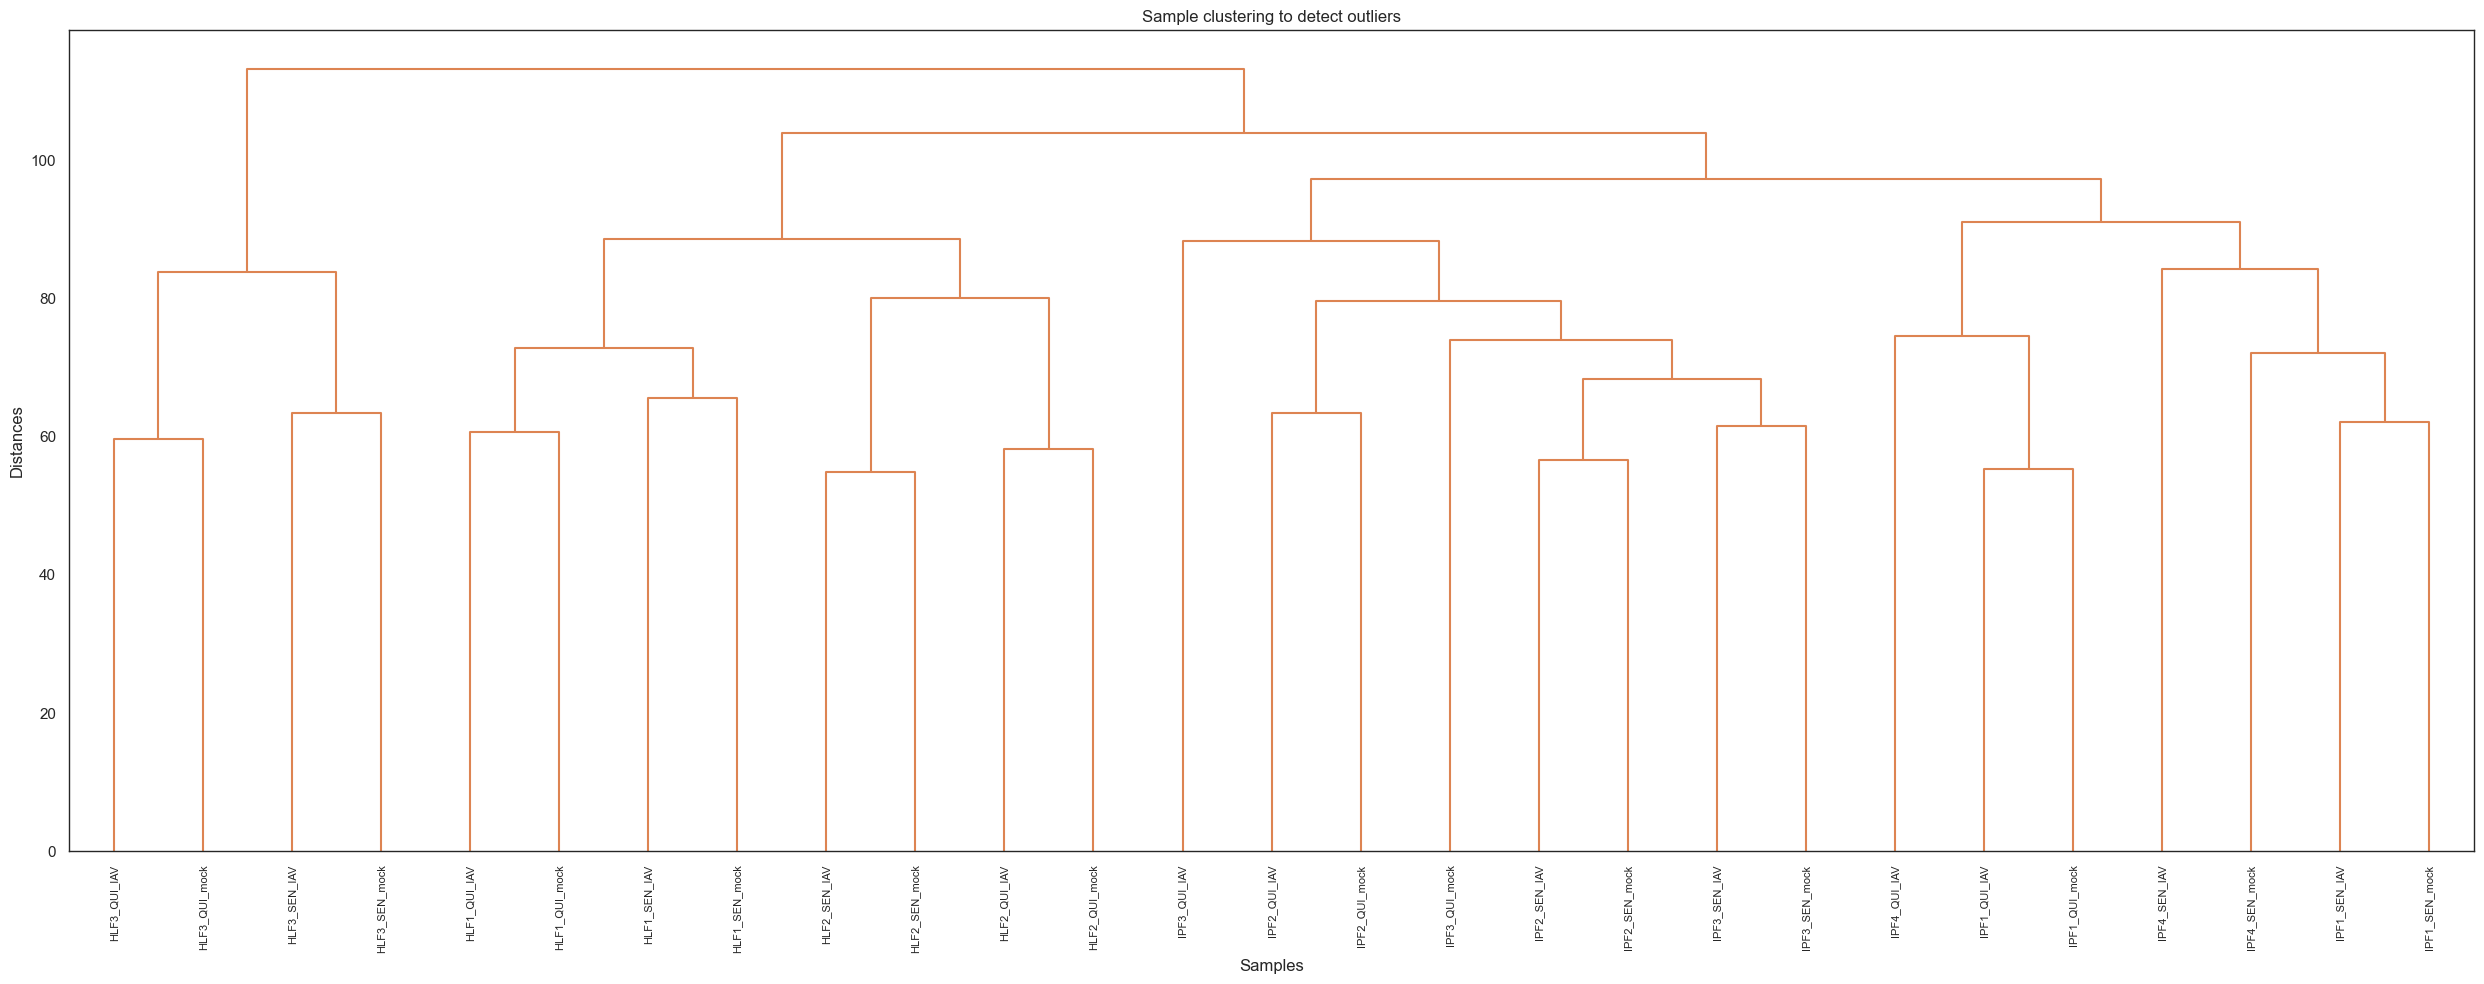

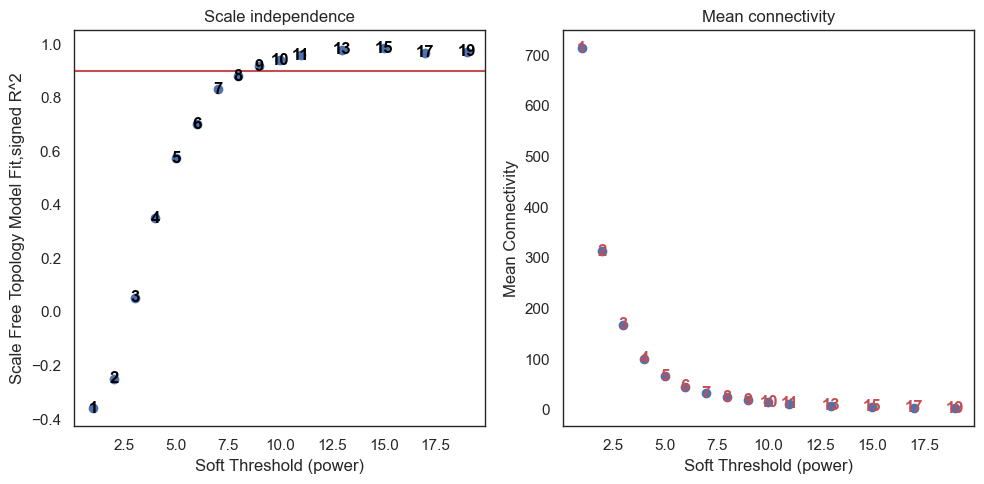

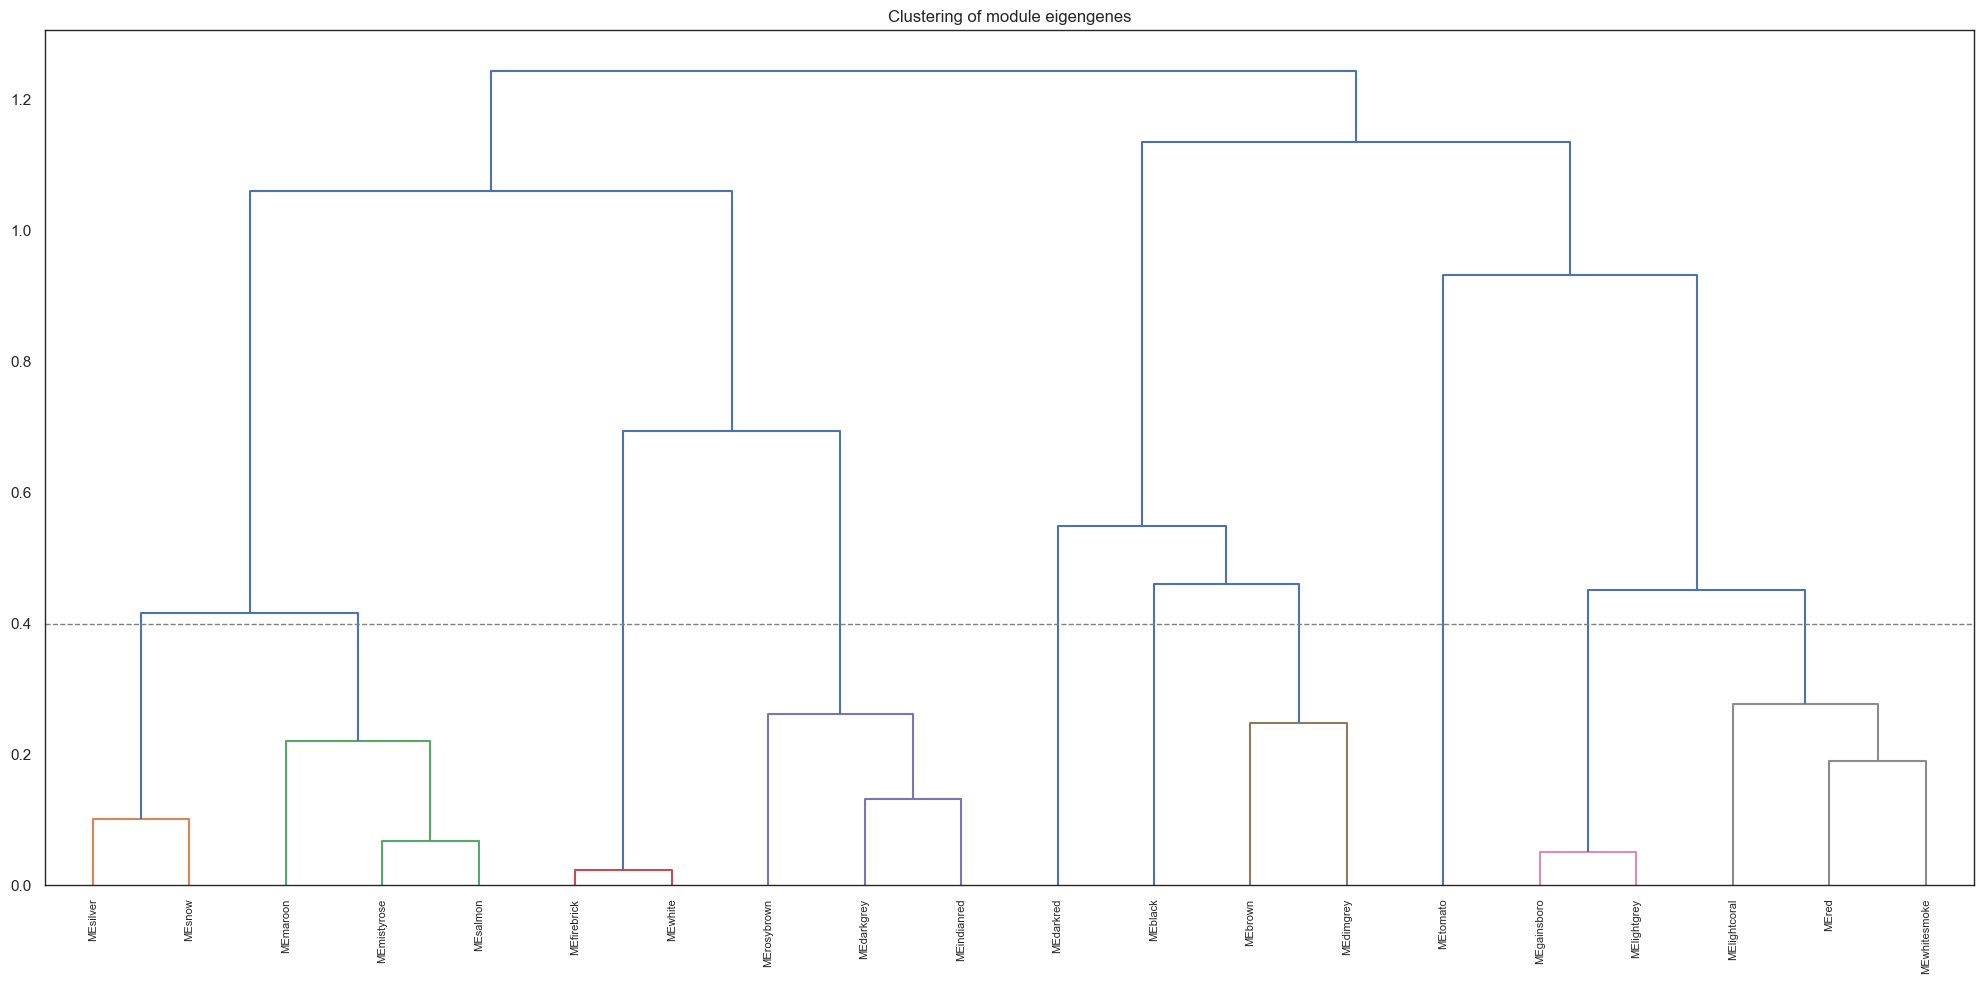

In [9]:
#Starting PyWGNCA
# If does not work 6-6-2024, try supplying geneExp directly without obs and var data, or just supply geneExpPath
# Did not work, made heatmaps with improper legend labeling, then errored out with same color array issue that included 'Fatbody' in colors 6-6-2024
# J080RNAseq_count_WGCNA = PyWGCNA.WGCNA(name='Jena_count_nonzero',
#                       species = 'homo sapiens',
#                       outputPath='Jena_count_DEseq2_batchCorrected_nonzero_50mod_0.4thresh_robustZ_diffNames',#'J080RNAseq',
#                       minModuleSize=50,
#                       MEDissThres=0.4, #default MEDissThres=0.2, set to 0.4, then 0.425 6-23-2024 and 6-25-2024 due to many eigengene branches barely missing 0.3 threshold
#                       geneExp=expression_data,
#                       # anndata=adata,
#                       save=True,
#                       figureType='png')

# J080RNAseq_count_WGCNA.geneExpr.to_df().head(10)

# J080RNAseq_count_WGCNA.preprocess() #pre-processing data

# J080RNAseq_count_WGCNA.findModules() #Constructing network in following steps:
# Choosing the soft-thresholding power: analysis of network topology
# Co-expression similarity and adjacency
# Topological Overlap Matrix (TOM)
# Clustering using TOM
# Merging of modules whose expression profiles are very similar

# We also can merge two previous steps by calling runWGCNA() function.
J080RNAseq_count_WGCNA.runWGCNA()

In [10]:
J080RNAseq_count_WGCNA.saveWGCNA()

Saving WGCNA as Jena_count_nonzero.p


In [25]:
# read in the wgcna. 
#J080RNAseq_count_WGCNA = PyWGCNA.readWGCNA("Jena_count_DEseq2_batchCorrected_nonzero_50mod_0.4thresh_robustZ_diffNamesJena_count_nonzero.p")

wgcna_path = os.path.join(out_dir, "Jena_count_nonzero.p")

J080RNAseq_count_WGCNA = PyWGCNA.readWGCNA(wgcna_path)


Reading Jena_count_nonzero WGCNA done!


In [26]:
# Checking status of RubedoRNAseq_count_WGCNA following runWGCNA()
J080RNAseq_count_WGCNA.datExpr.var.head(10)
J080RNAseq_count_WGCNA.datExpr.obs.head(10)
J080RNAseq_count_WGCNA.geneExpr.obs.head(10)
J080RNAseq_count_WGCNA.geneExpr.var.head(10)

# Updating sample info and giving tissues color, doesn't seem necessary if included in AnnData object. They only supplied expression data in tutorial example
J080RNAseq_count_WGCNA.updateSampleInfo(path='Jena_metadata_modified2_batch.csv', sep=',')#'Rubedo_metadata.csv', sep=',')
#RubedoRNAseq_count_WGCNA.updateSampleInfo(sample_metadata) fixed the issue when index column was pointing to the incorrect column

# Updating sample info and giving tissues color, doesn't seem necessary if included in AnnData object. They only supplied expression data in tutorial example
#J080RNAseq_count_WGCNA.updateSampleInfo(path='Jena_metadata_modified2_copy.csv', sep=',')#'J080_metadata.csv', sep=',')

In [27]:
J080RNAseq_count_WGCNA.datExpr.obs

,tube_folder_label,cell_label,condition,infection,timepoint,sex,age,disease,serum,batch
sample_id,,,,,,,,,,
HLF1_QUI_IAV,HLF1_QUI_IAV,AJAZ,CTL,IAV,24,NaN,42,normal,SS,batch2
HLF1_QUI_mock,HLF1_QUI_mock,AJAZ,CTL,mock,24,NaN,42,normal,SS,batch2
HLF1_SEN_IAV,HLF1_SEN_IAV,AJAZ,IR,IAV,264,NaN,42,normal,SS,batch2
HLF1_SEN_mock,HLF1_SEN_mock,AJAZ,IR,mock,264,NaN,42,normal,SS,batch2
HLF2_QUI_IAV,HLF2_QUI_IAV,HLF250,CTL,IAV,24,Male,48,normal,SS,batch2
HLF2_QUI_mock,HLF2_QUI_mock,HLF250,CTL,mock,24,Male,48,normal,SS,batch2
HLF2_SEN_IAV,HLF2_SEN_IAV,HLF250,IR,IAV,264,Male,48,normal,SS,batch2
HLF2_SEN_mock,HLF2_SEN_mock,HLF250,IR,mock,264,Male,48,normal,SS,batch2
HLF3_QUI_IAV,HLF3_QUI_IAV,AJDL,CTL,IAV,24,NaN,41,normal,SS,batch2


In [28]:

# add color for metadata
#J080RNAseq_count_WGCNA.setMetadataColor('sex', {'Male': 'blue',
#                                       'Female': 'red'})
J080RNAseq_count_WGCNA.setMetadataColor('infection', {'mock': 'blue',
                                       'IAV': 'red'})
J080RNAseq_count_WGCNA.setMetadataColor('condition', {'CTL': 'green',
                                       'IR': 'yellow'})
#J080RNAseq_count_WGCNA.setMetadataColor('timepoint', {'24': 'purple',
#                                       '264': 'black'})
#timepoint won't run at the moment but don't really need it for this analysis
J080RNAseq_count_WGCNA.setMetadataColor('disease', {'normal': 'orange',
                                       'IPF': 'green'})
#J080RNAseq_count_WGCNA.setMetadataColor('batch', {'batch1': 'gray',#
#                                       'batch2': 'purple'})

#J080RNAseq_count_WGCNA.setMetadataColor('cell_label', {
#    'A27' : 'purple', 'A31' : 'black', 'A37' : 'pink', 'A48' : 'orange', 'ID48' : 'green'})
# FS add extra columns

# Setting this metadatacolor below. If that doesn't work, can uncomment the below line and run
# J080RNAseq_count_WGCNA.setMetadataColor('age', {'27': 'green',
#                                        '31': 'yellow',
#                                        '37': 'orange',
#                                        '48': 'purple',
#                                        '66': 'pink'})

# Getting gene information from biomart
# geneList = PyWGCNA.getGeneList(dataset='hsapiens_gene_ensembl',
#                                attributes=['ensembl_gene_id', 
#                                            'external_gene_name', 
#                                            'gene_biotype'],
#                                maps=['gene_id', 'gene_name', 'gene_biotype'])

#Updating gene info, it might need fb number to successfully update using this method
# J080RNAseq_count_WGCNA.updateGeneInfo(gene_metadata_red)#geneList)

# Removing sample name from gene and data information columns, removed 'age' separately because it was giving issues with color assignments in analyzeWGCNA() below
#if 'id' in J080RNAseq_count_WGCNA.datExpr.obs.columns:
    #J080RNAseq_count_WGCNA.datExpr.obs = J080RNAseq_count_WGCNA.datExpr.obs.drop(columns=['OriginalName', 'id', 'disease', 'seq notes', 'sequencing'])
#J080RNAseq_count_WGCNA.datExpr.obs = J080RNAseq_count_WGCNA.datExpr.obs.drop(columns=['sample', 'folder_label', 'timepoint', 'ApoE', 'dx.at.biopsy', 
#                                                                                          'current.dx', 'disease', 'sequencing', 'seq.notes'])
    
##if 'id' in J080RNAseq_count_WGCNA.datExpr.var.columns:
    #J080RNAseq_count_WGCNA.datExpr.var = J080RNAseq_count_WGCNA.datExpr.var.drop(columns=['OriginalName', 'id', 'disease', 'seq notes', 'sequencing'])
#J080RNAseq_count_WGCNA.datExpr.var = J080RNAseq_count_WGCNA.datExpr.var.drop(columns=['sample', 'folder_label', 'timepoint', 'ApoE', 'dx.at.biopsy', 
#                                                                                          'current.dx', 'disease', 'sequencing', 'seq.notes'])

#Extracting adjacency matrix, if wanted
# J080RNAseq_count_WGCNA_TOM = J080RNAseq_count_WGCNA.TOM
# J080RNAseq_count_WGCNA_TOM.to_csv(J080RNAseq_count_WGCNA.outputPath+'figures/J080RNAseq_count_WGCNA_TOM.csv')

# List of unique sample IDs
#unique_ages = J080RNAseq_count_WGCNA.datExpr.obs['age'].unique()

# List of colors
#colors = generate_colors(unique_ages) #['cyan', 'magenta', 'lime', 'maroon', 'navy']#

# Ensure there are enough colors for the unique sample IDs
#assert len(colors) >= len(unique_ages), "Not enough colors for the unique sample IDs."

# Create the mapping dictionary
#sample_id_to_color = {sample_id: color for sample_id, color in zip(unique_ages, colors)}

# Assuming J080RNAseq_count_WGCNA is your WGCNA object
#J080RNAseq_count_WGCNA.setMetadataColor('age', sample_id_to_color)


In [29]:
print(J080RNAseq_count_WGCNA.datExpr.obs.columns)
#sample_id not in the dataframe, so can't drop it but might be able to take it out later when doing heatmap comparisons


Index(['tube_folder_label', 'cell_label', 'condition', 'infection',
       'timepoint', 'sex', 'age', 'disease', 'serum', 'batch'],
      dtype='object')


In [30]:
#J080RNAseq_count_WGCNA.datExpr.obs.drop(columns=['age'], inplace=True)


In [31]:
J080RNAseq_count_WGCNA.datExpr.obs.drop(columns=['sex', 'age', 'serum', 'tube_folder_label', 'timepoint',
                                        'cell_label', 'batch'], inplace=True)

In [32]:
J080RNAseq_count_WGCNA.datExpr.obs.head(5)

,condition,infection,disease
sample_id,,,
HLF1_QUI_IAV,CTL,IAV,normal
HLF1_QUI_mock,CTL,mock,normal
HLF1_SEN_IAV,IR,IAV,normal
HLF1_SEN_mock,IR,mock,normal
HLF2_QUI_IAV,CTL,IAV,normal


In [33]:
# Added by FS. - for continuous variables
#import matplotlib as mpl
#norm = mpl.colors.Normalize(vmin=min(J080RNAseq_count_WGCNA.datExpr.obs['age']), 
#                            vmax=max(J080RNAseq_count_WGCNA.datExpr.obs['age']))
#cmap = mpl.colormaps['viridis']
#J080RNAseq_count_WGCNA.setMetadataColor('age', mpl.cm.ScalarMappable(norm, cmap))

In [34]:
J080RNAseq_count_WGCNA.outputPath = "Jena_count_DEseq2_batchCorrected_nonzero_50mod_0.4thresh_robustZ_diffNames/"
import os

os.makedirs(
    os.path.join(J080RNAseq_count_WGCNA.outputPath, "figures"),
    exist_ok=True
)

#this needs to be the folder outside of the figures folder

Analysing WGCNA...
Calculating module trait relationship ...
	Done..

Adding (signed) eigengene-based connectivity (module membership) ...
	Done..

plotting module heatmap eigengene...
	Done..

plotting module barplot eigengene...
	Done..

doing Enrichr GO analysis for each module...
	gene name didn't found in gene information!
	 Go term analysis can not be done
	Done..



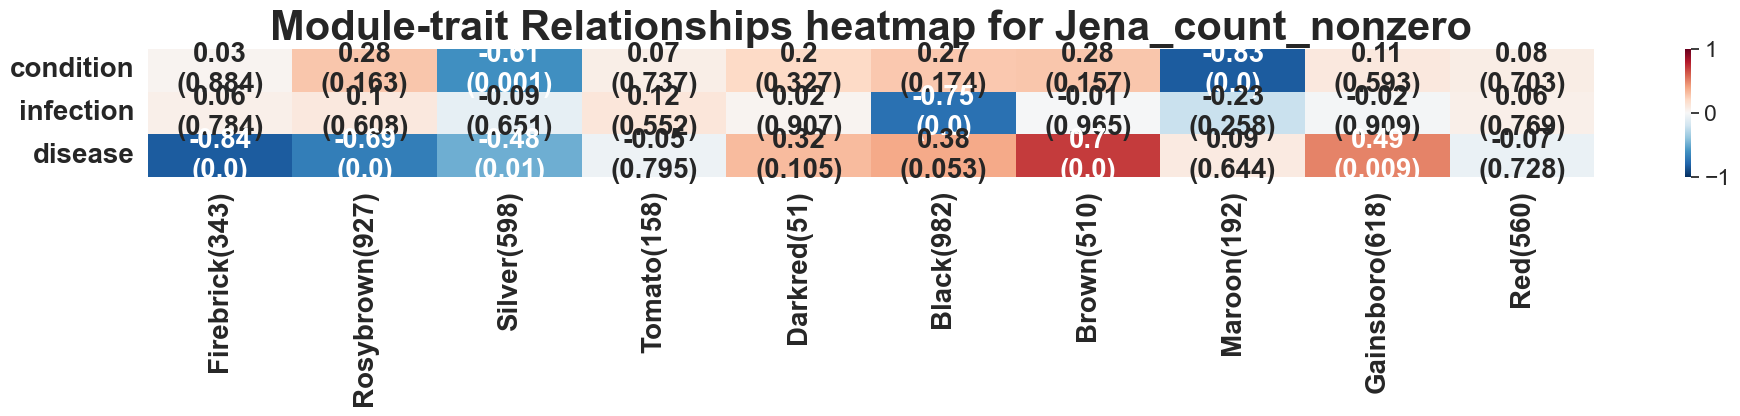

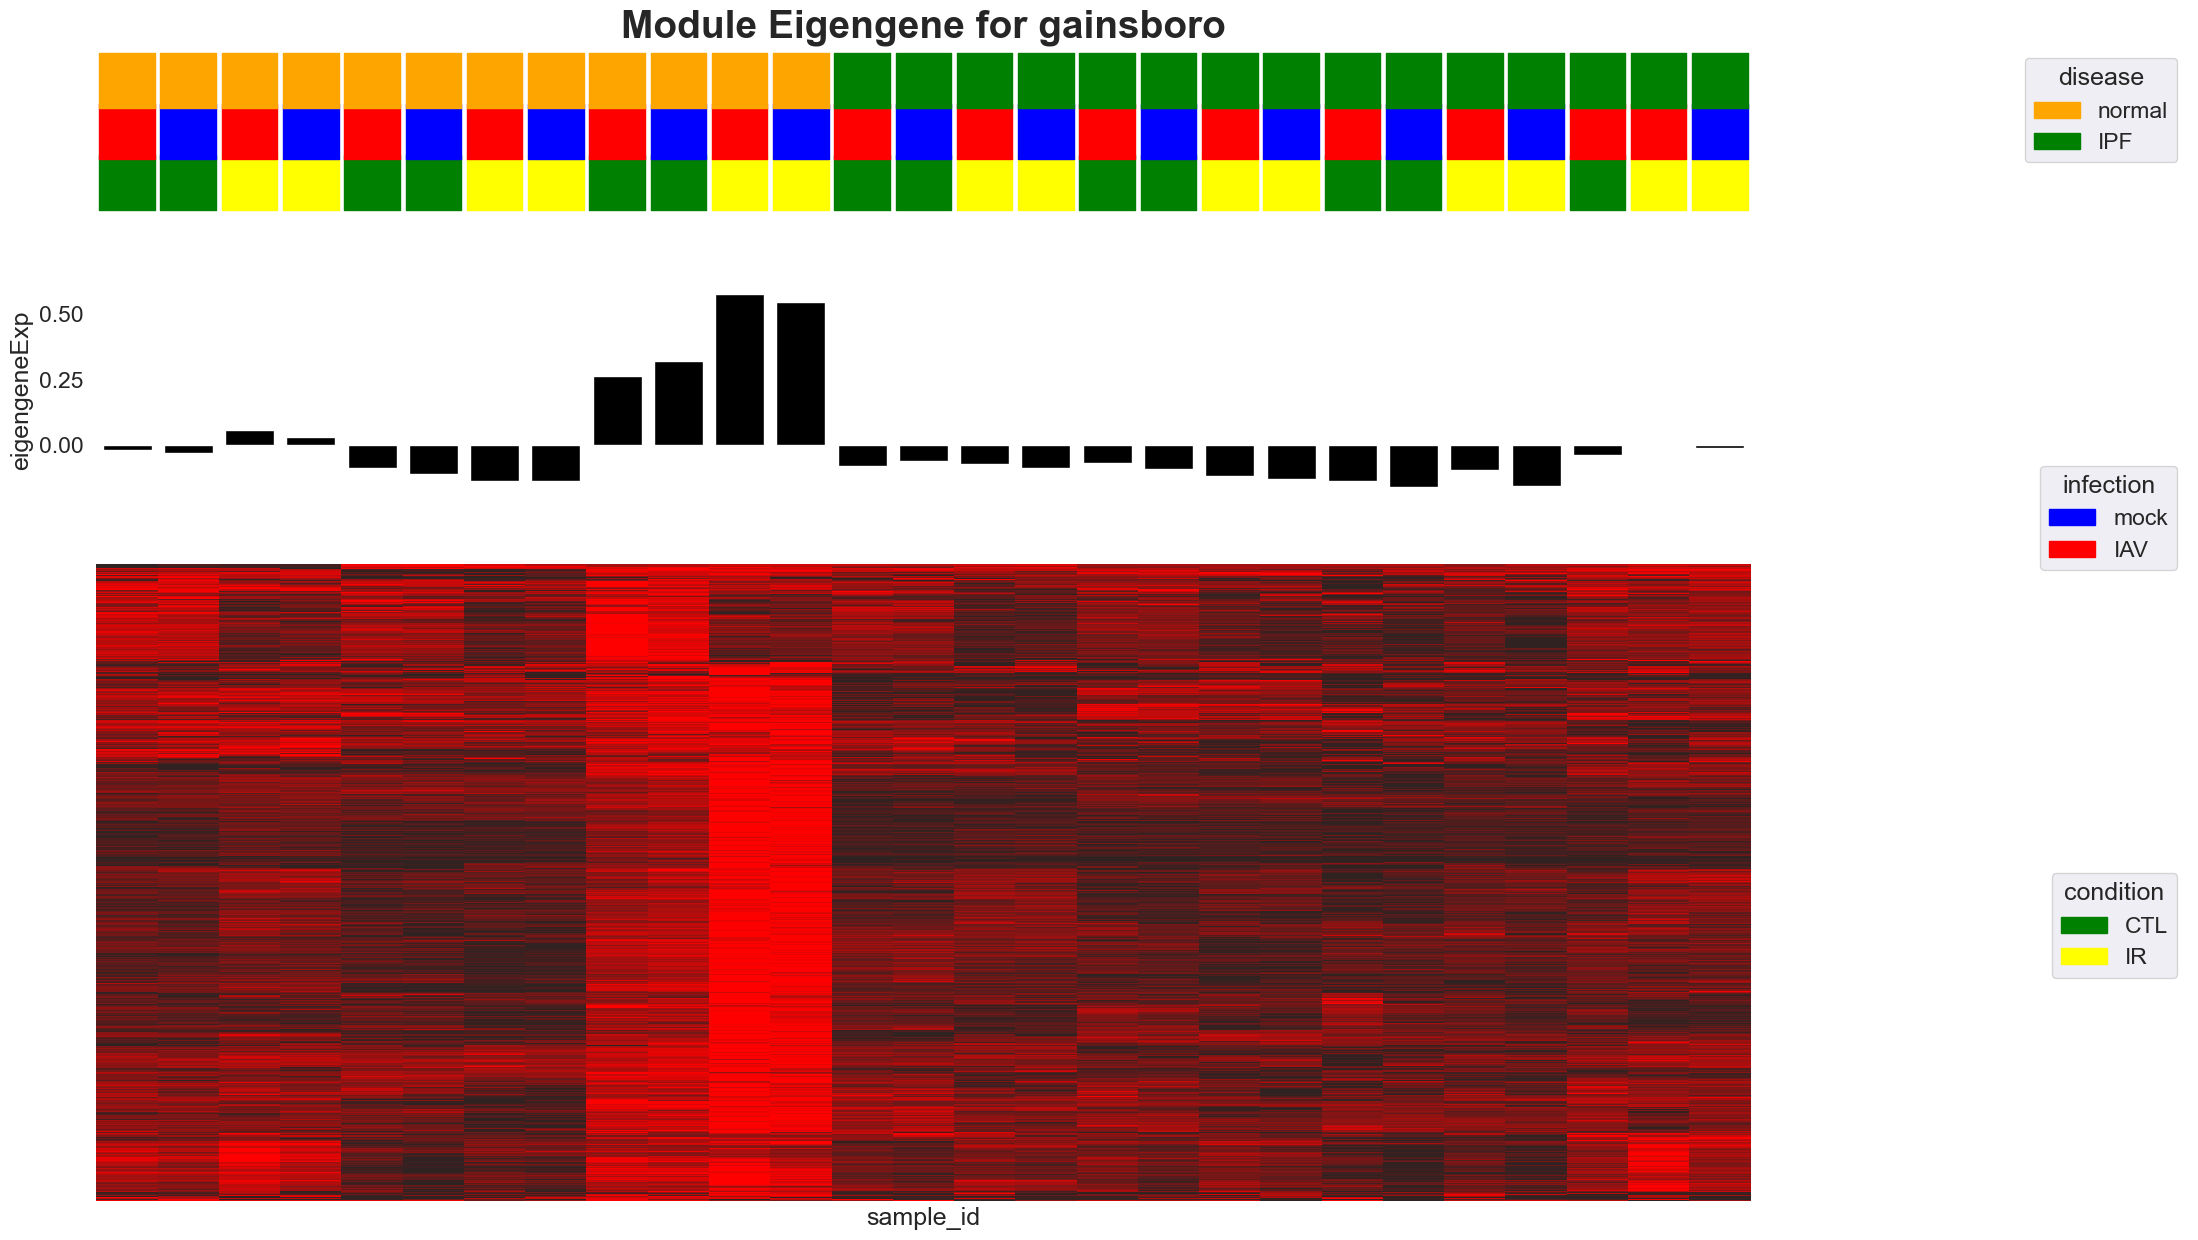

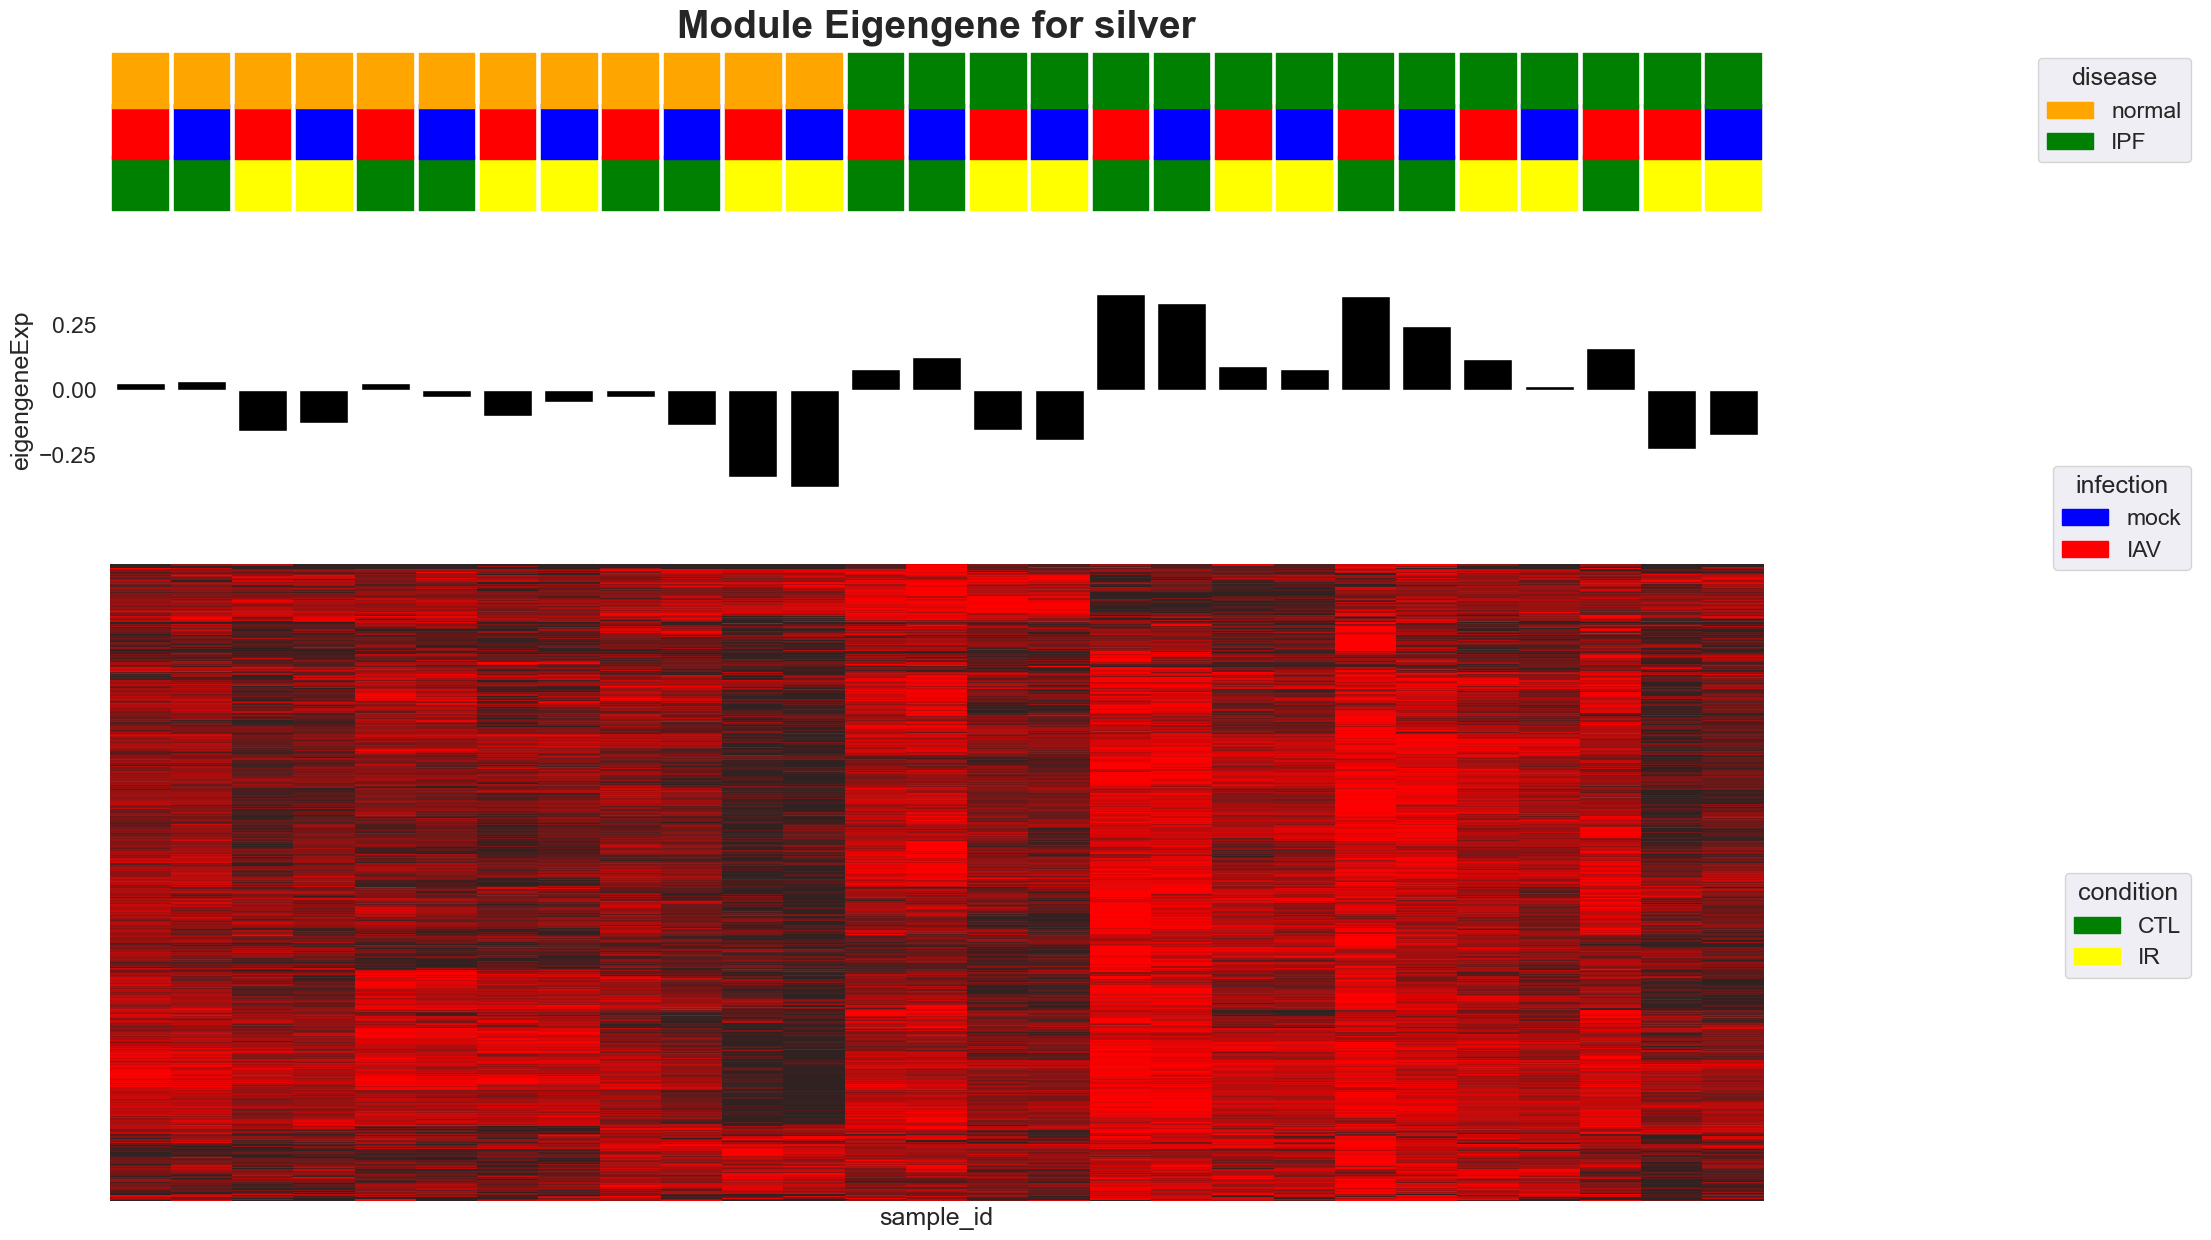

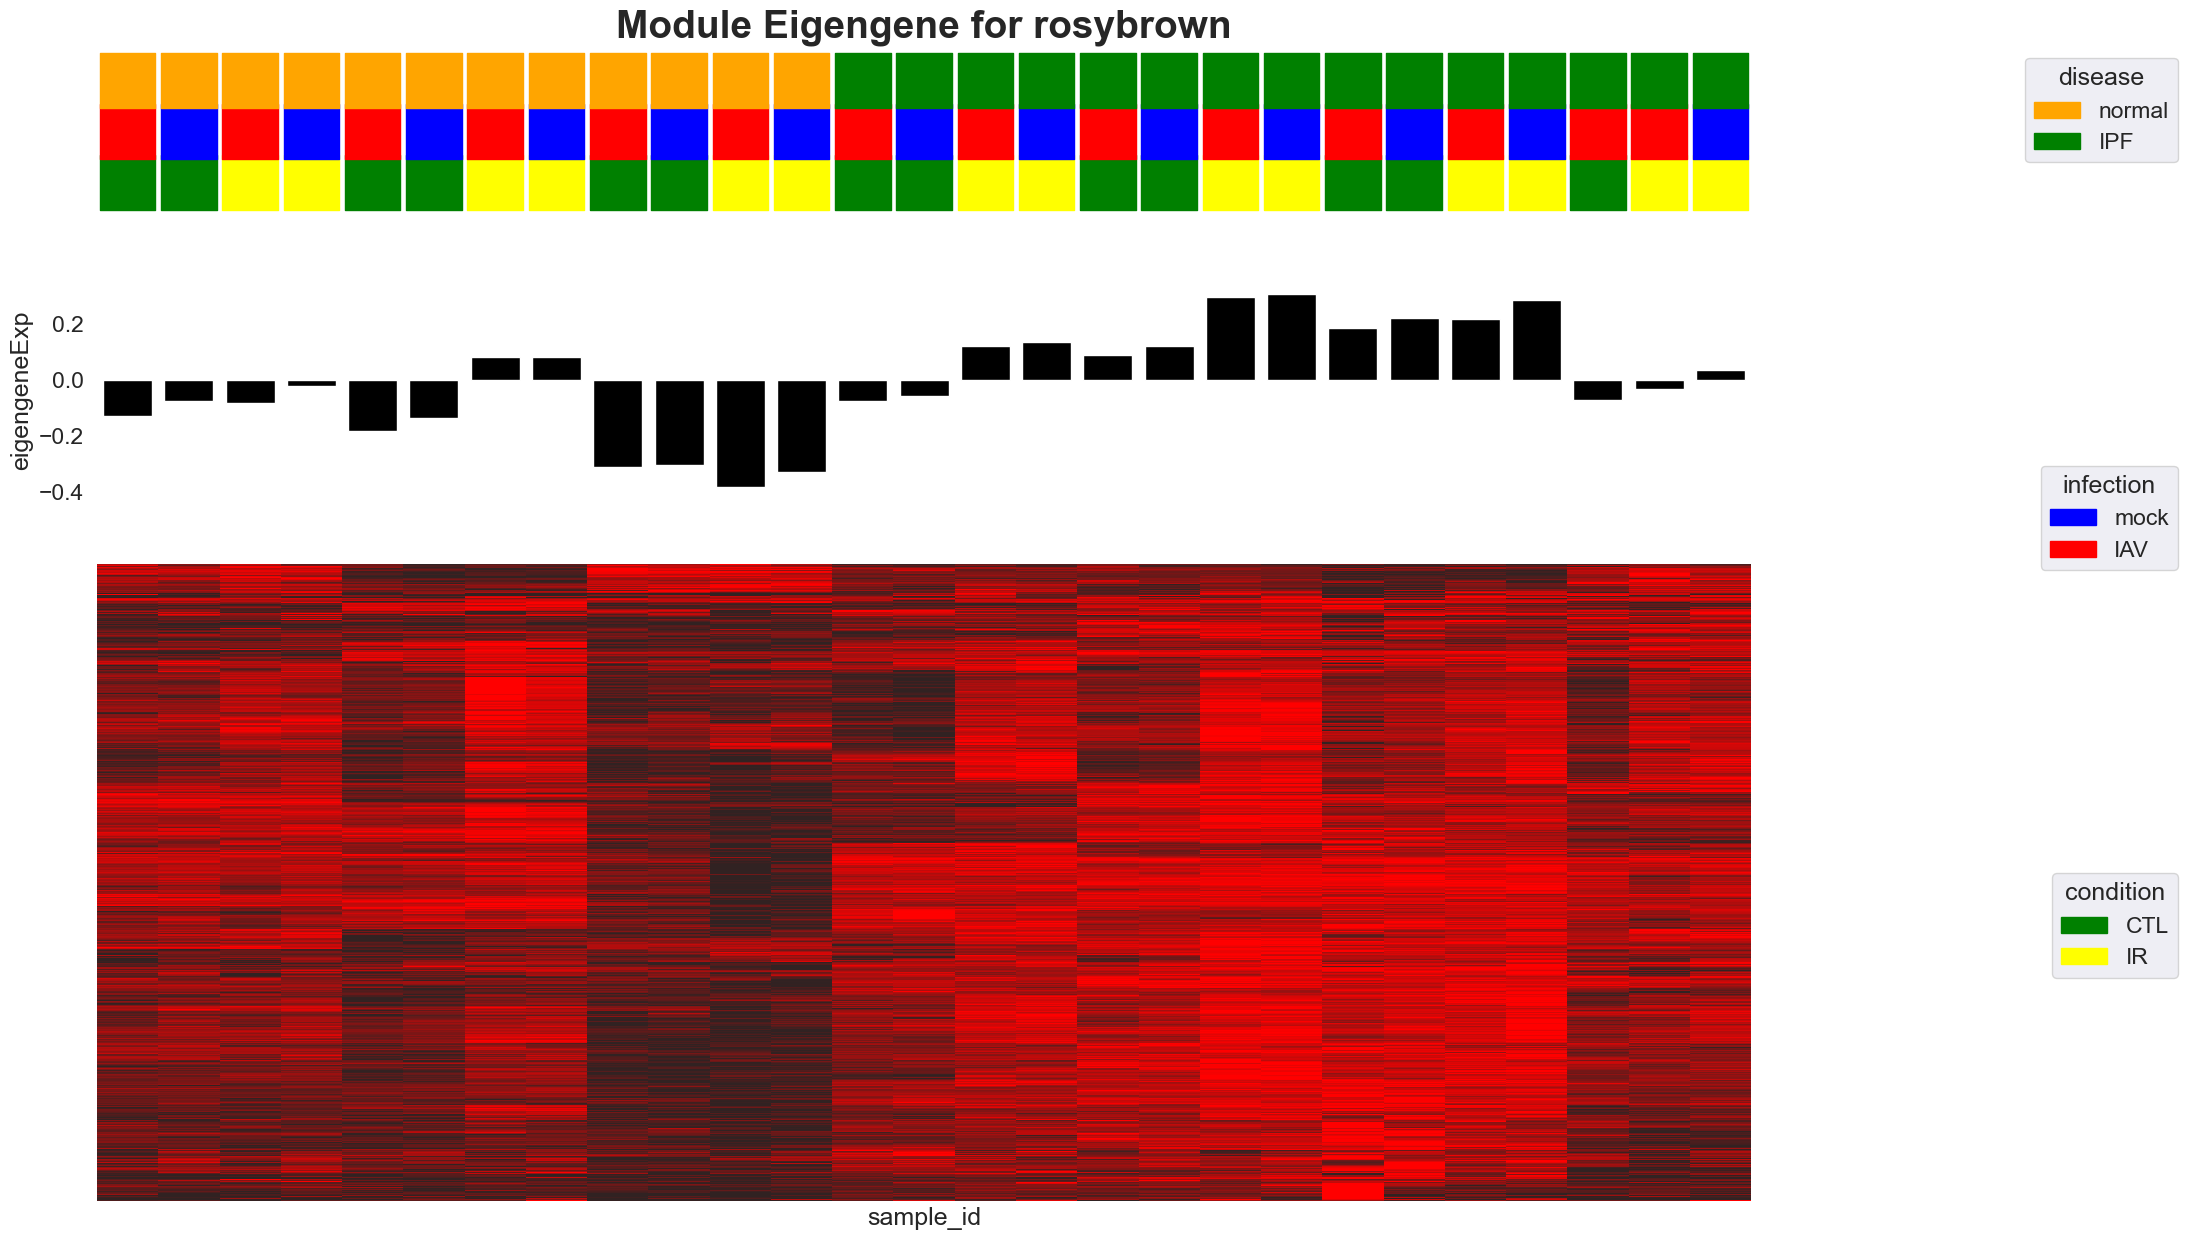

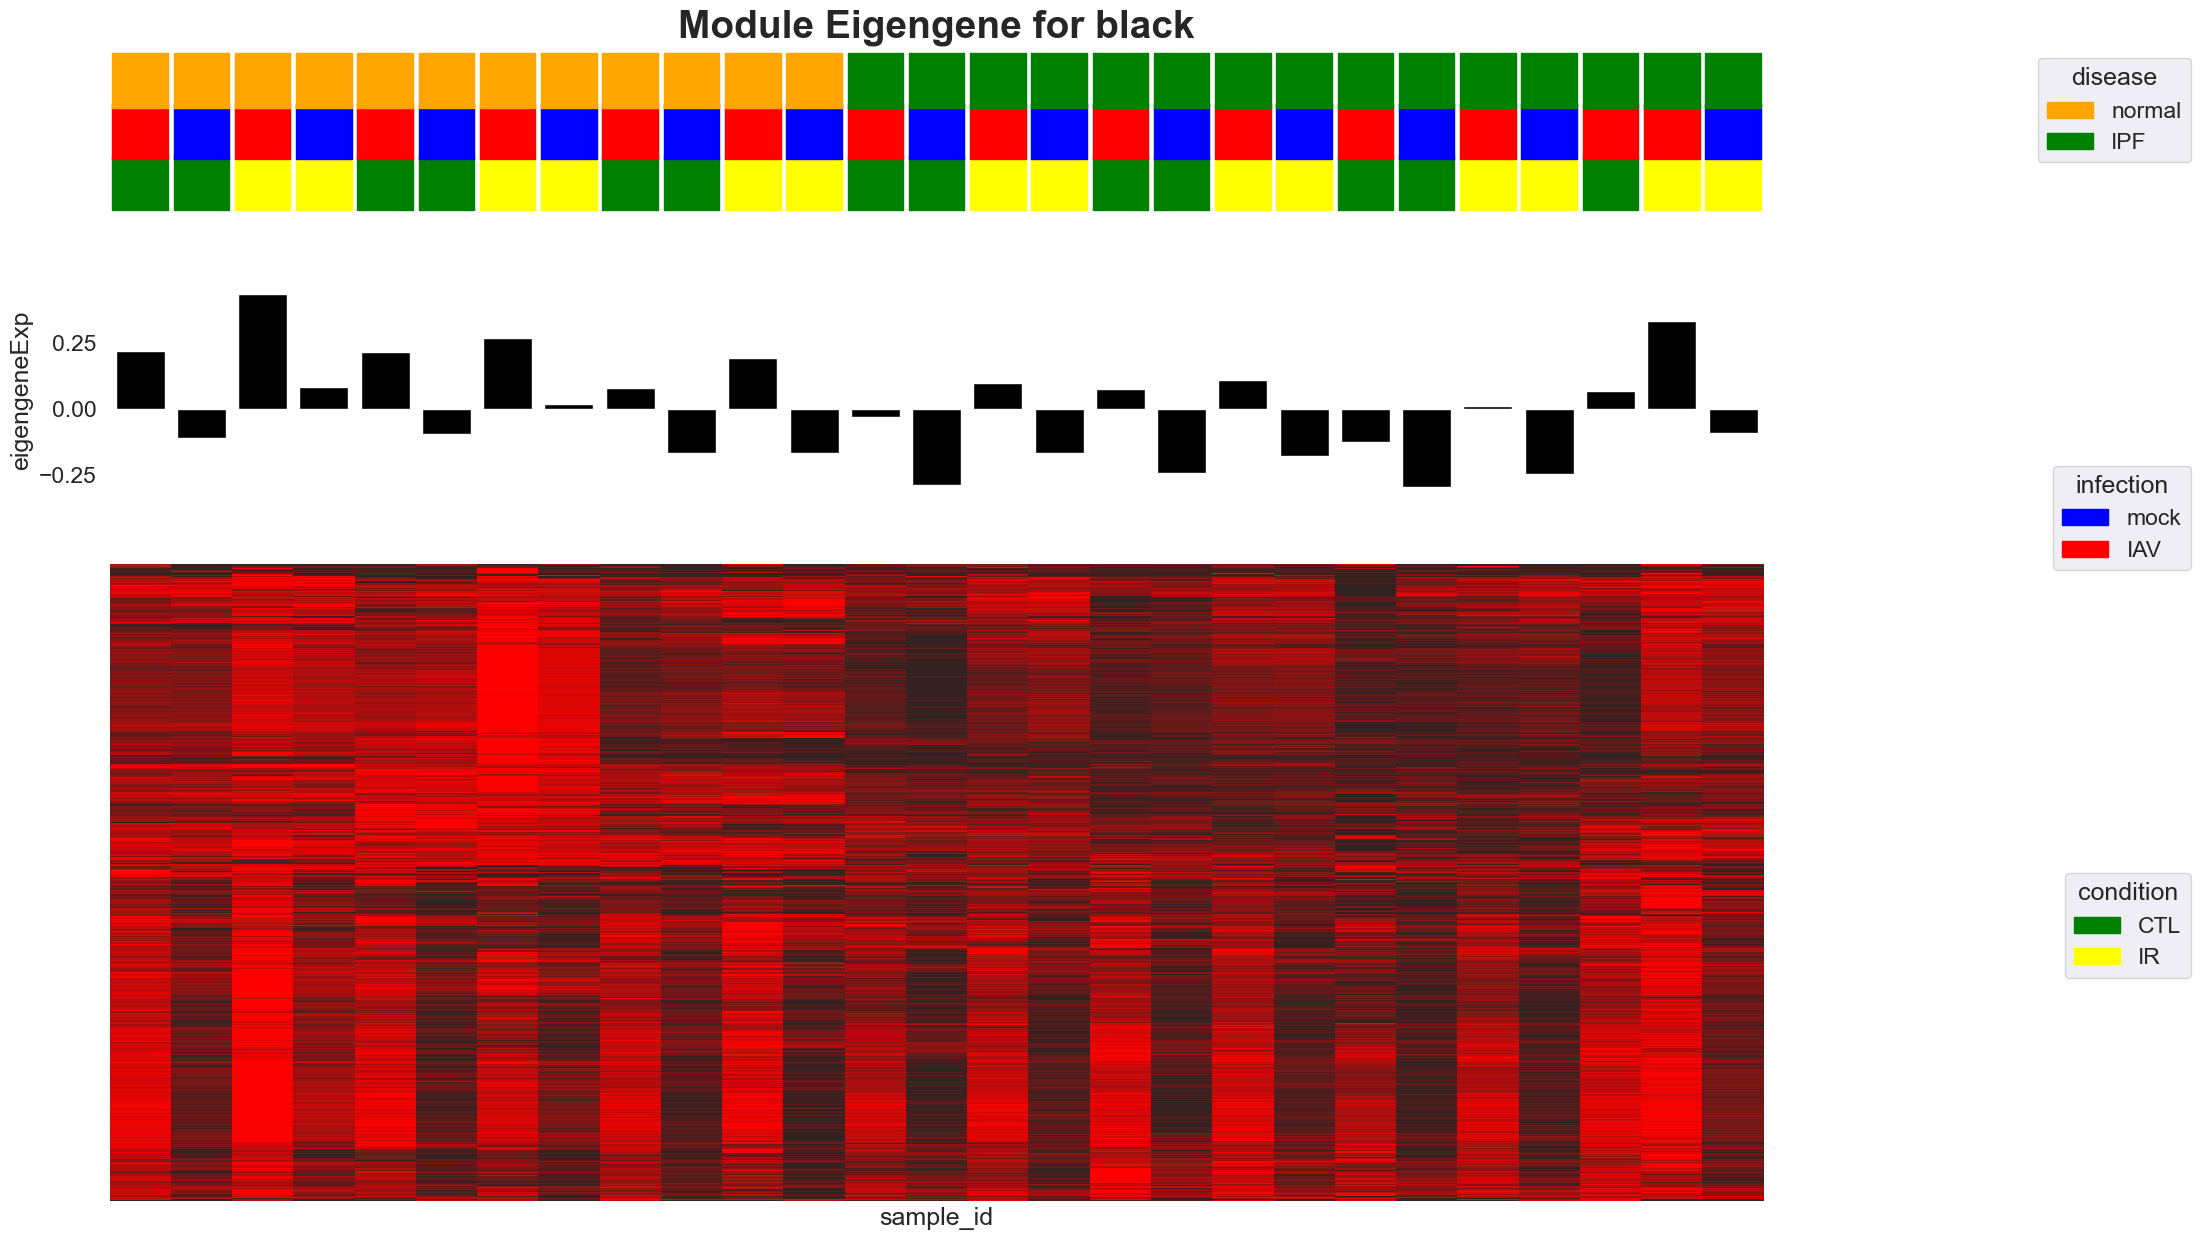

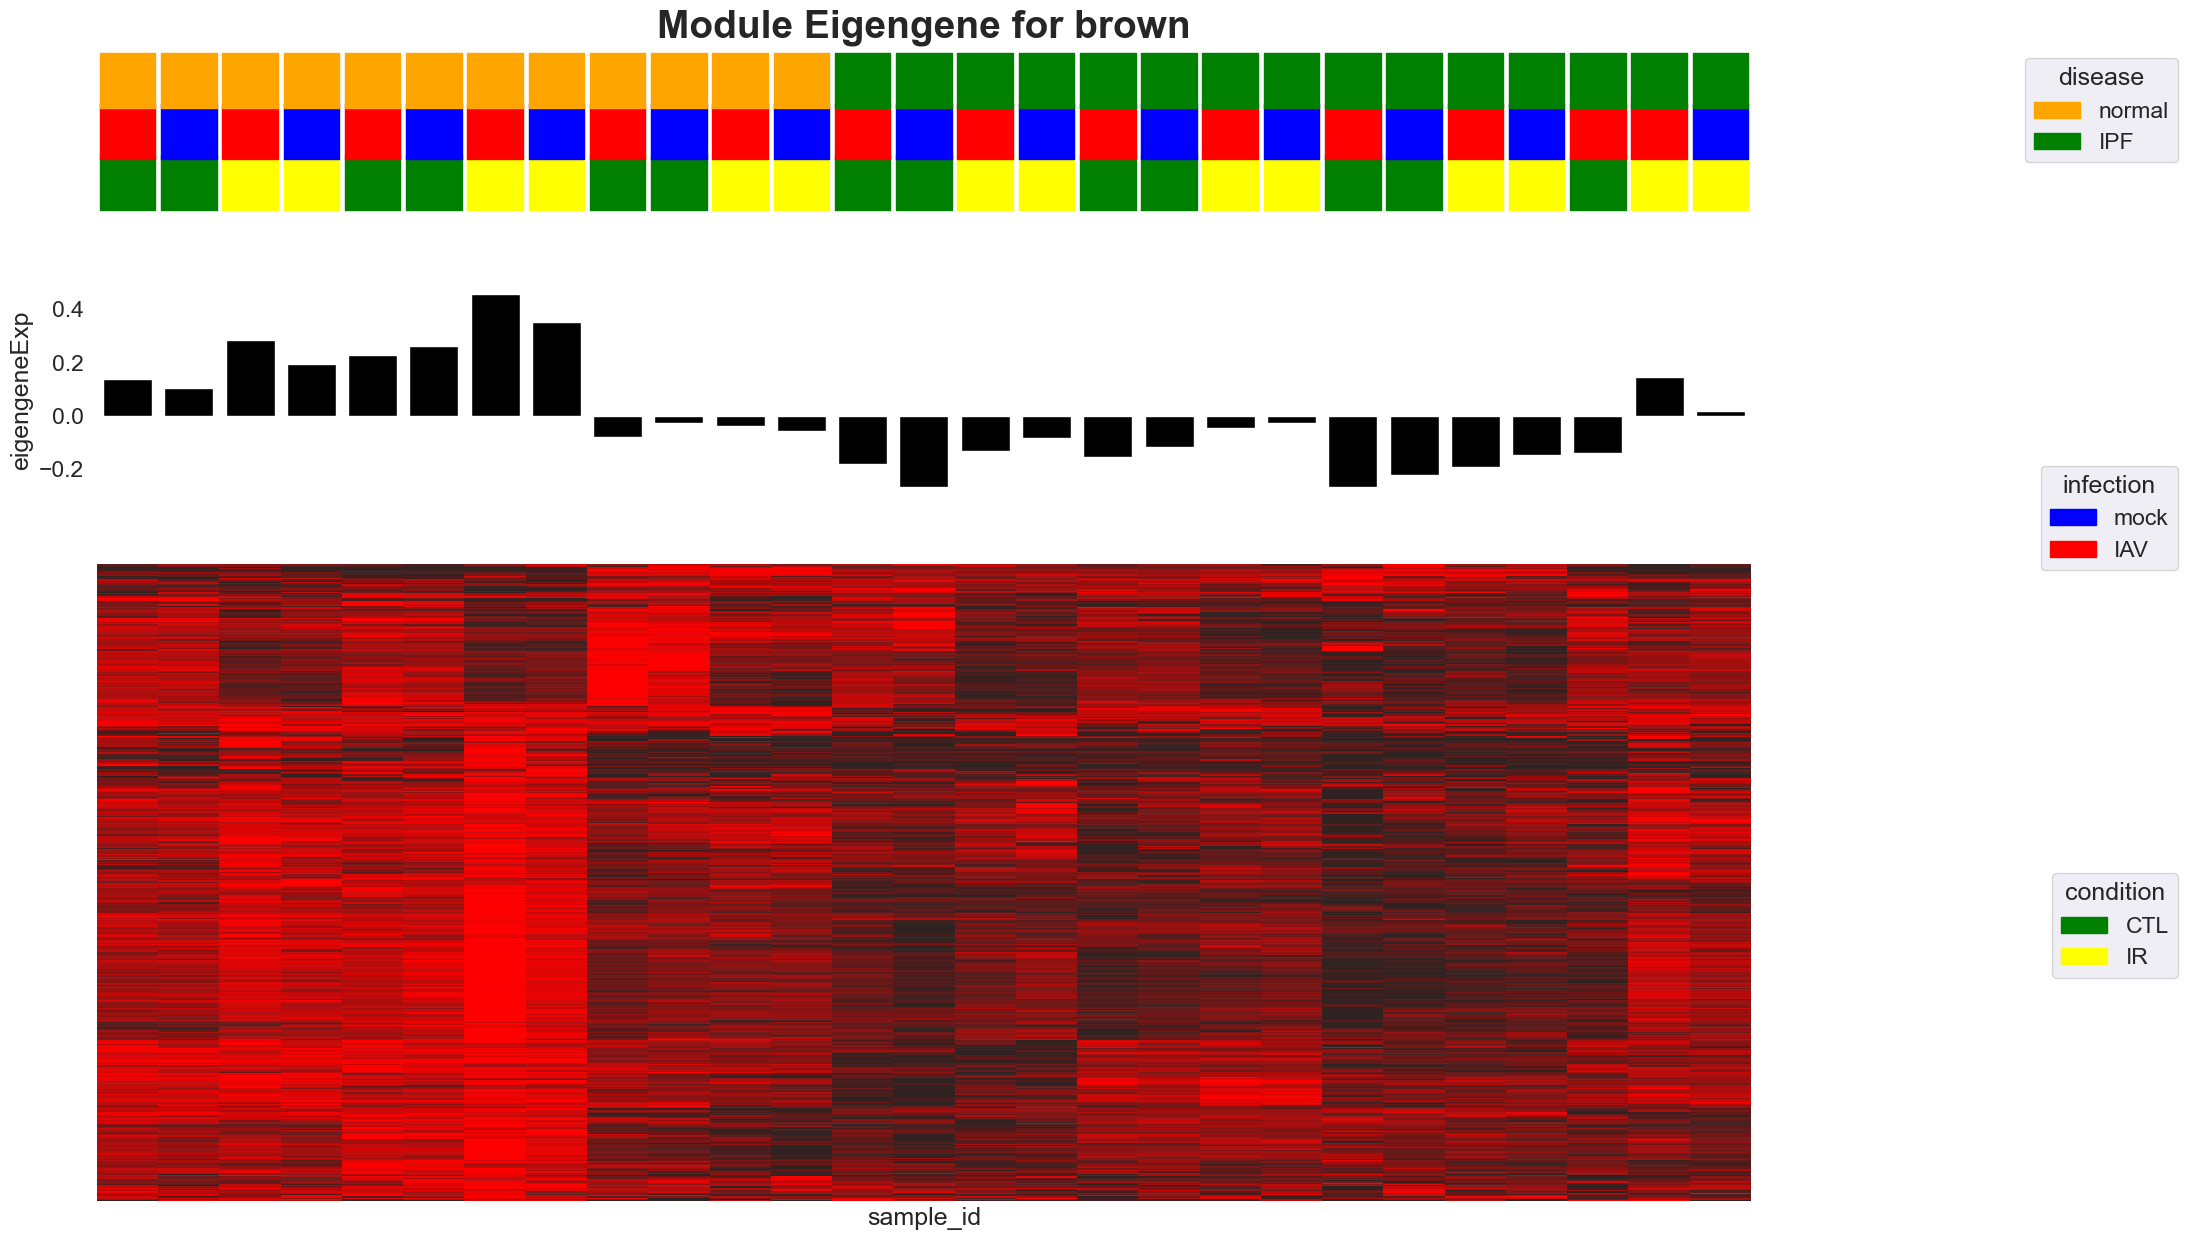

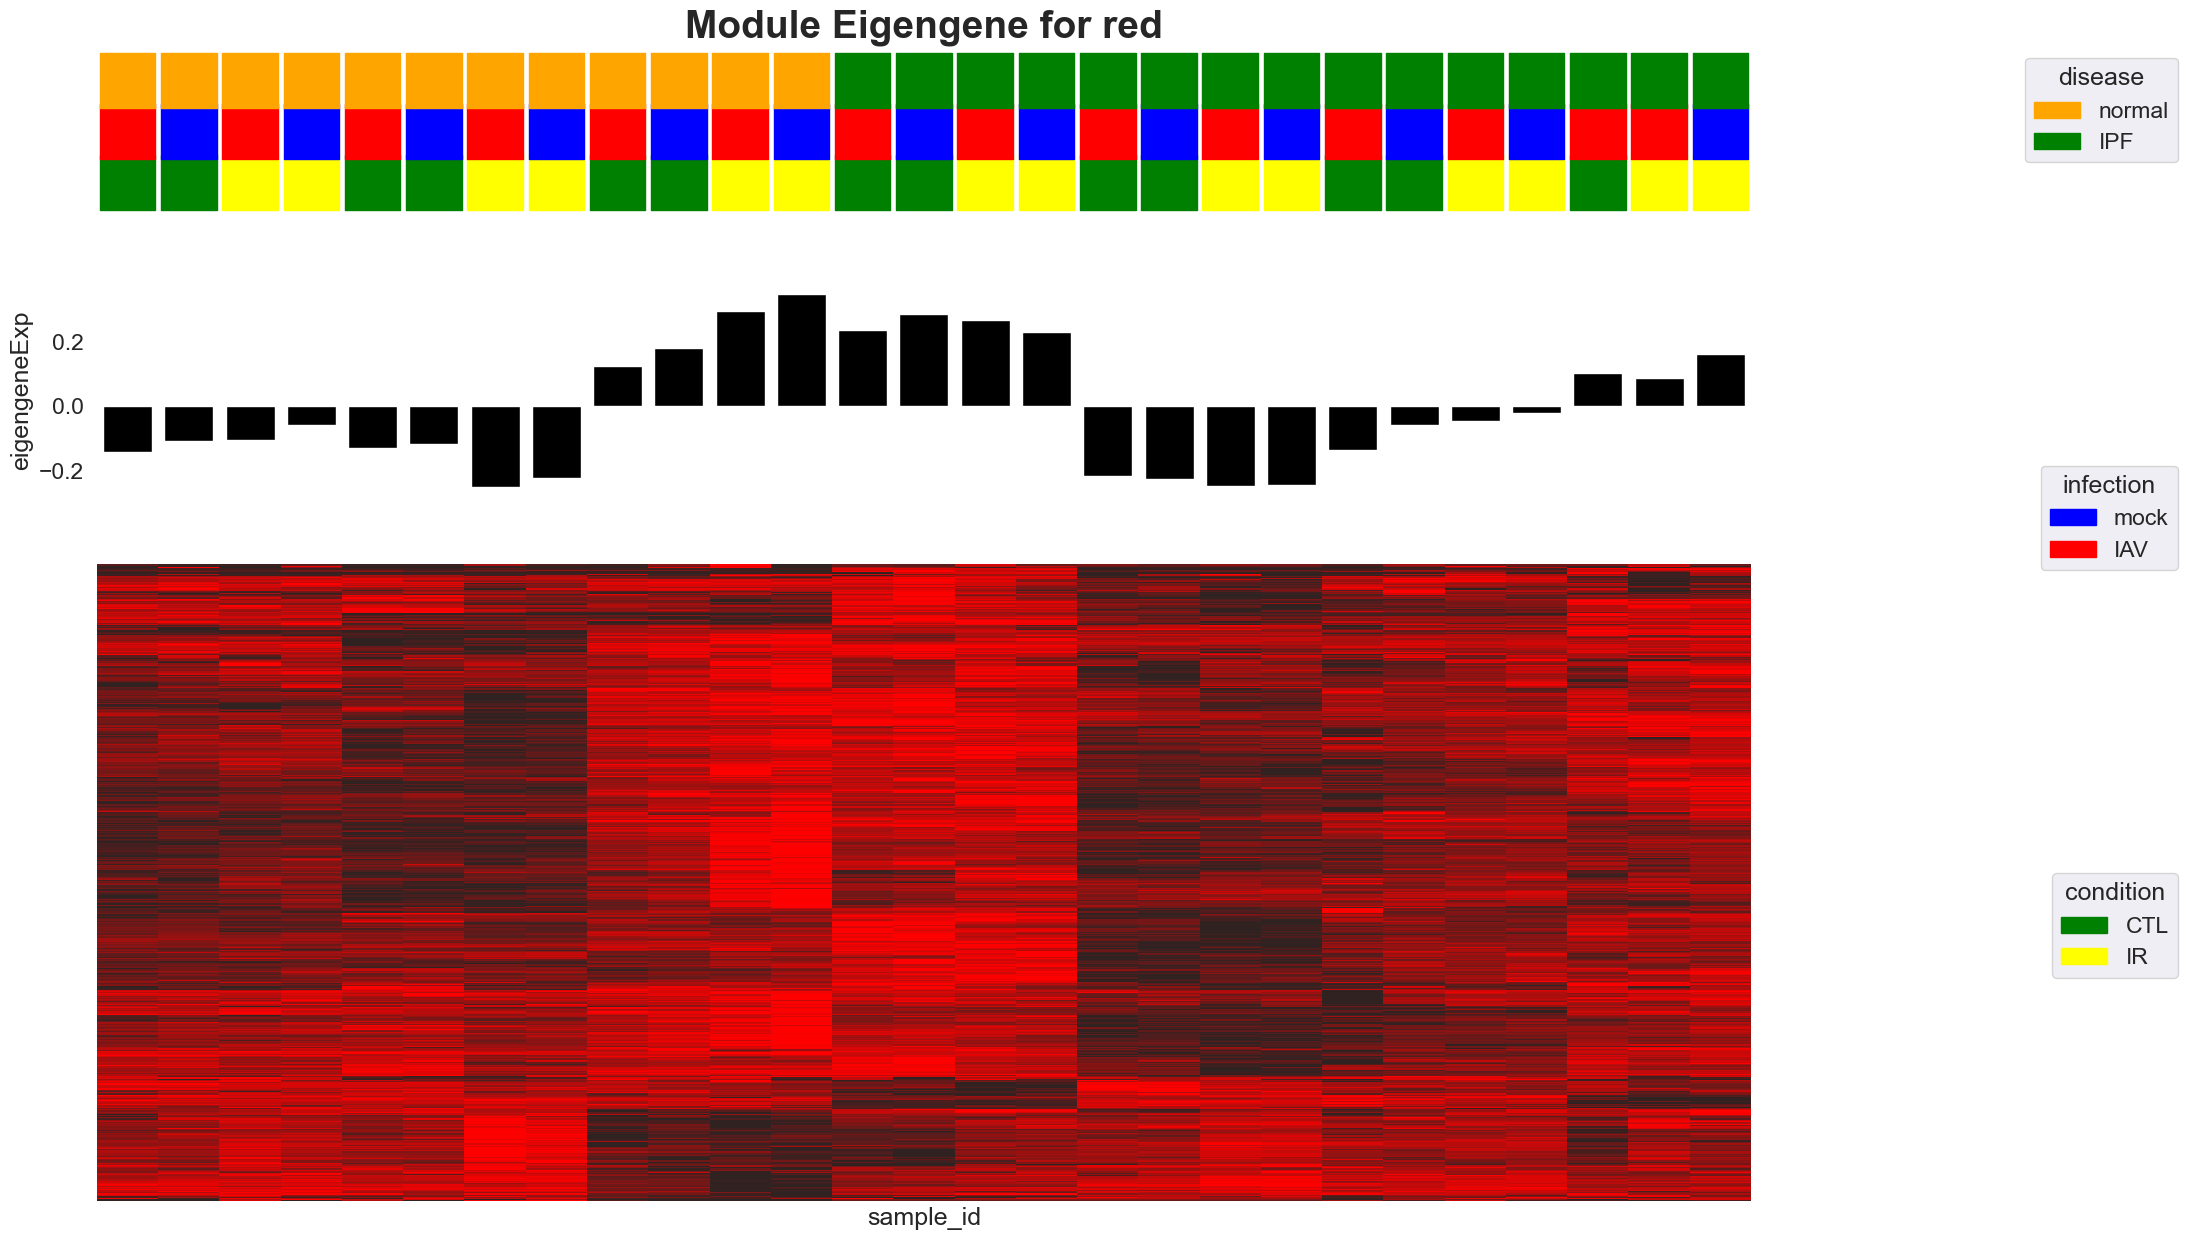

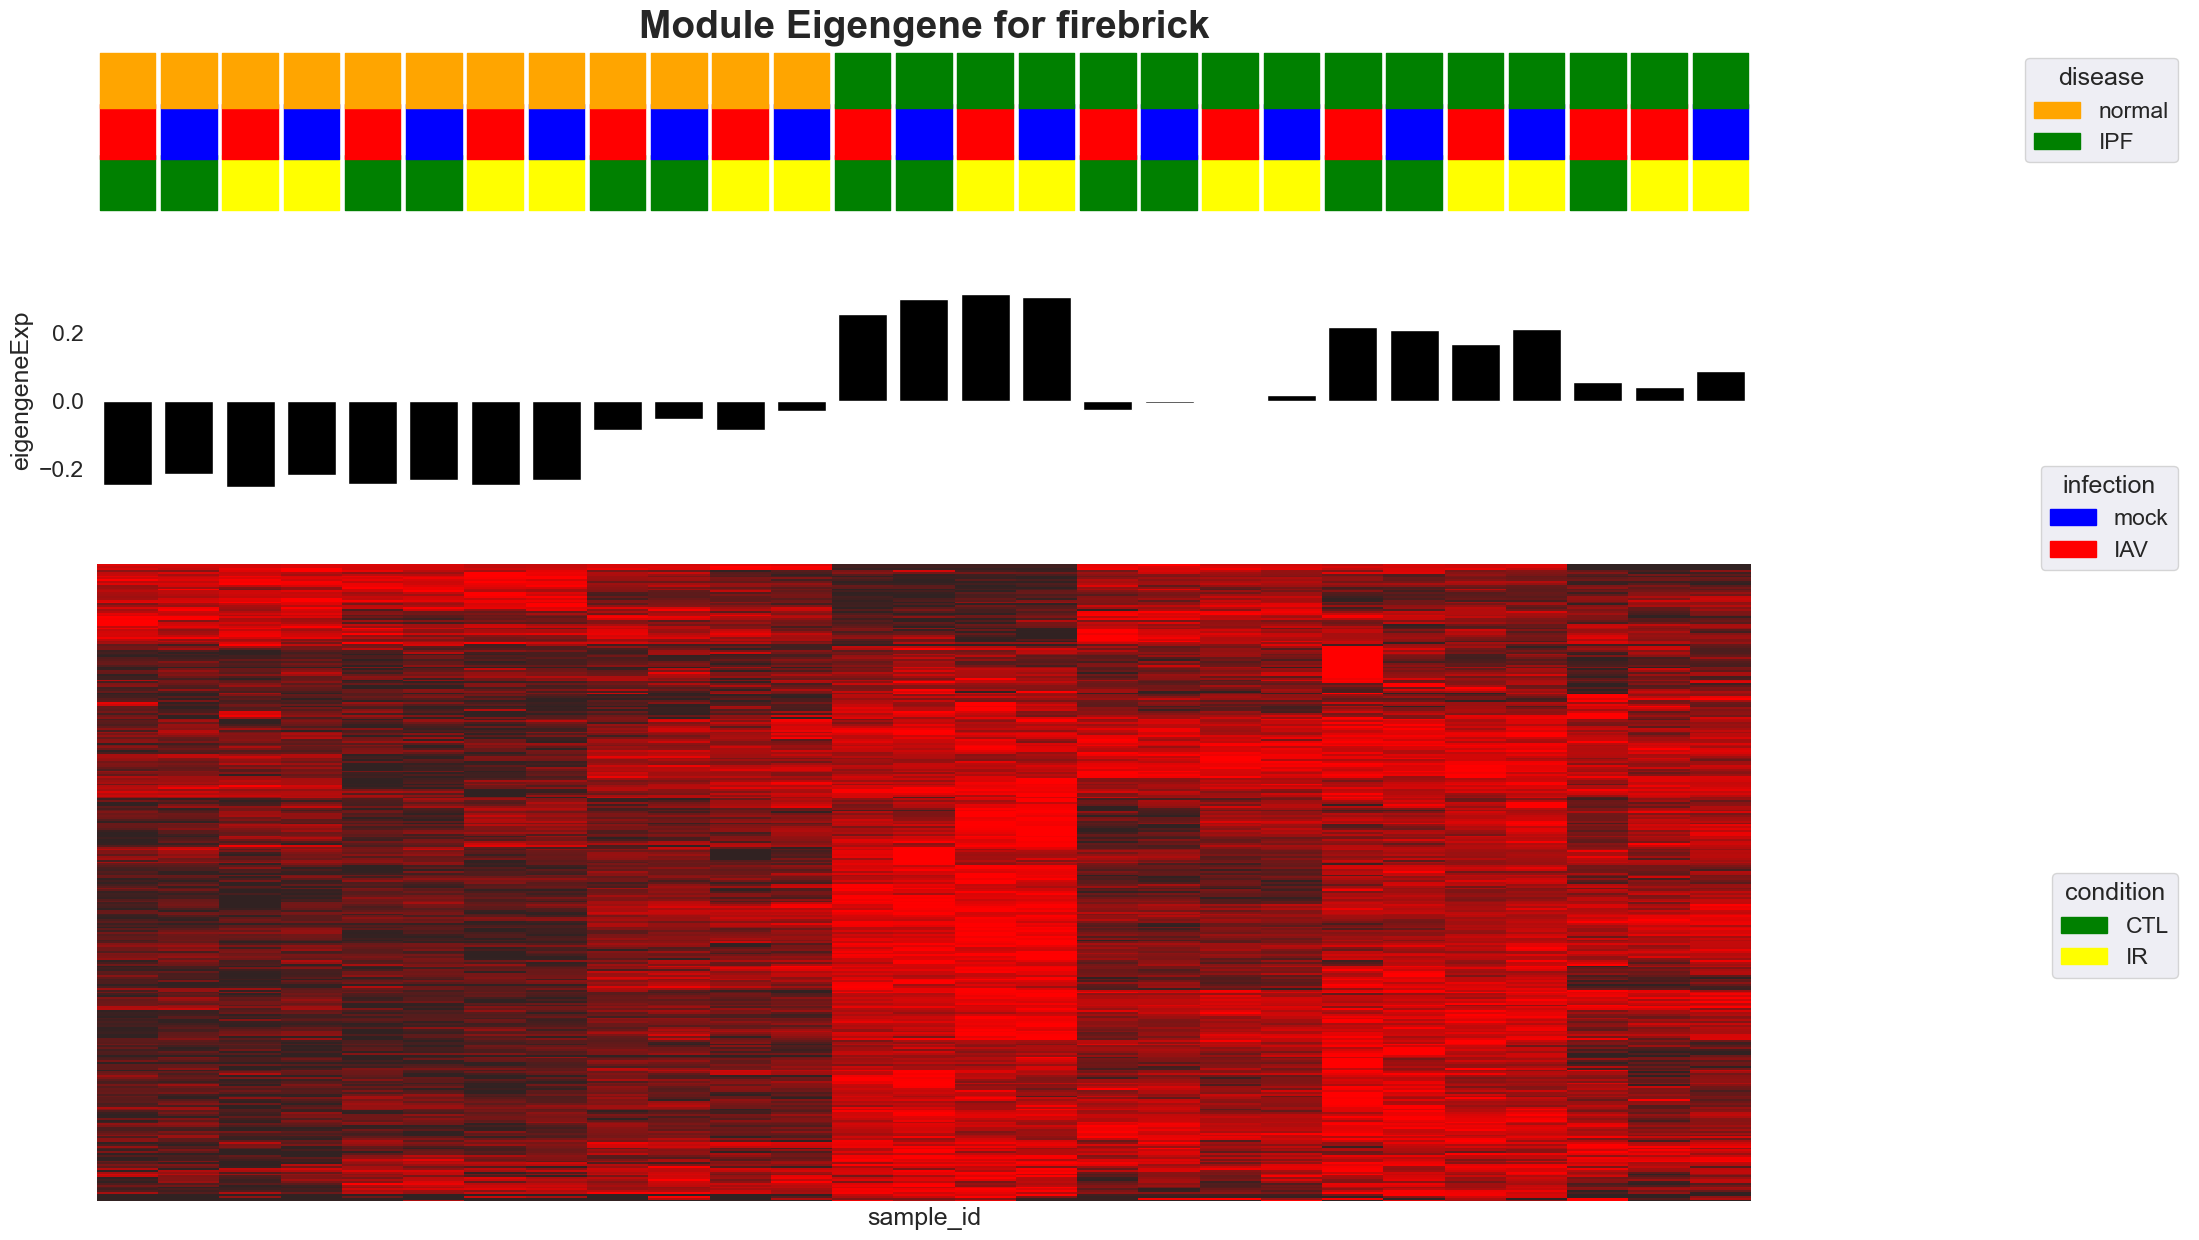

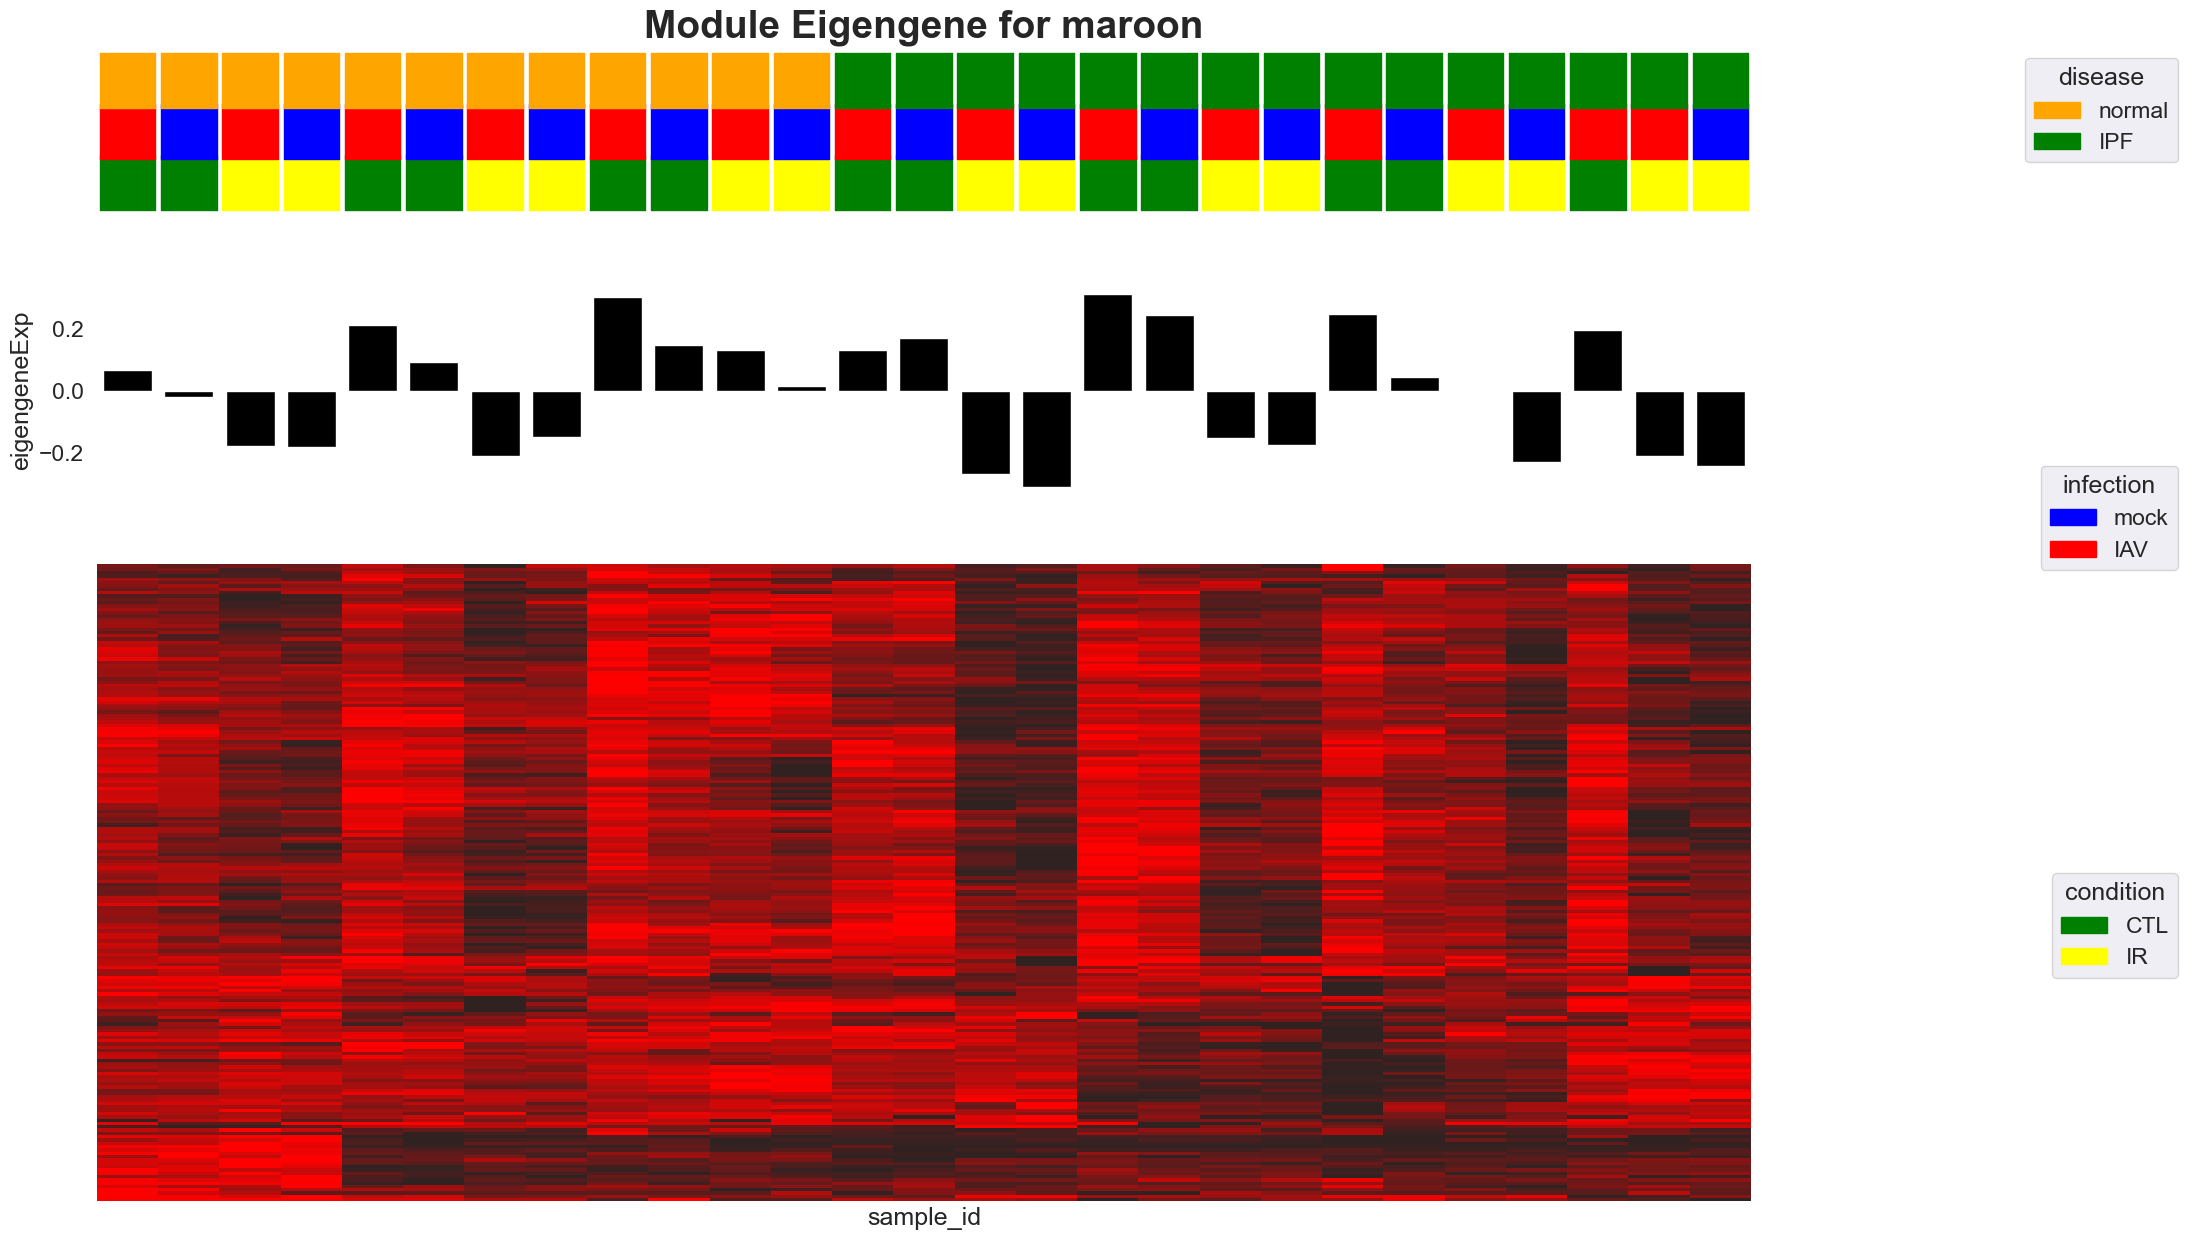

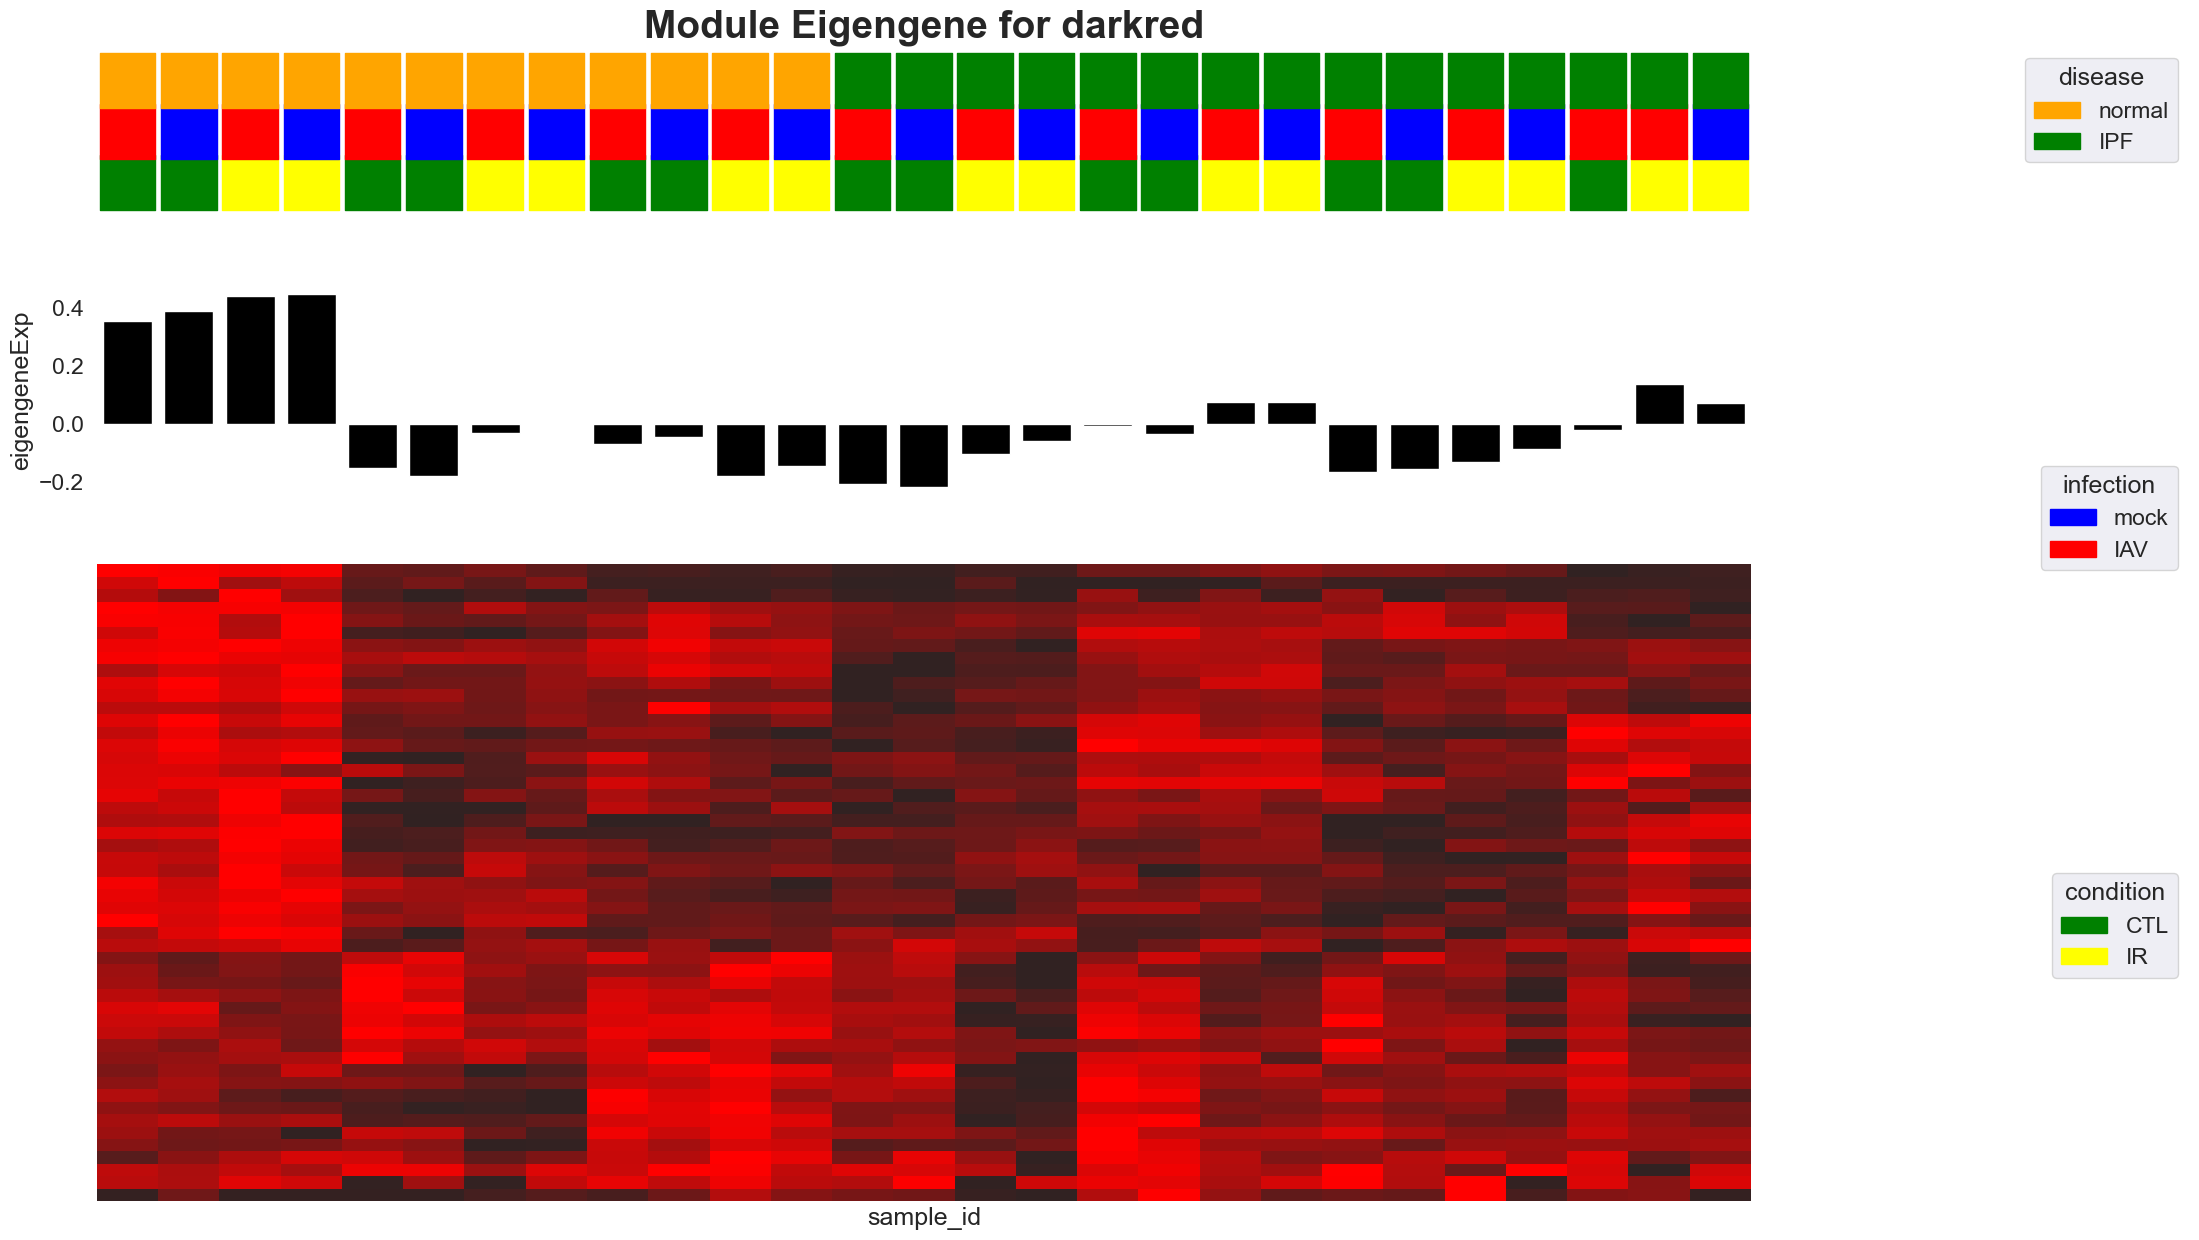

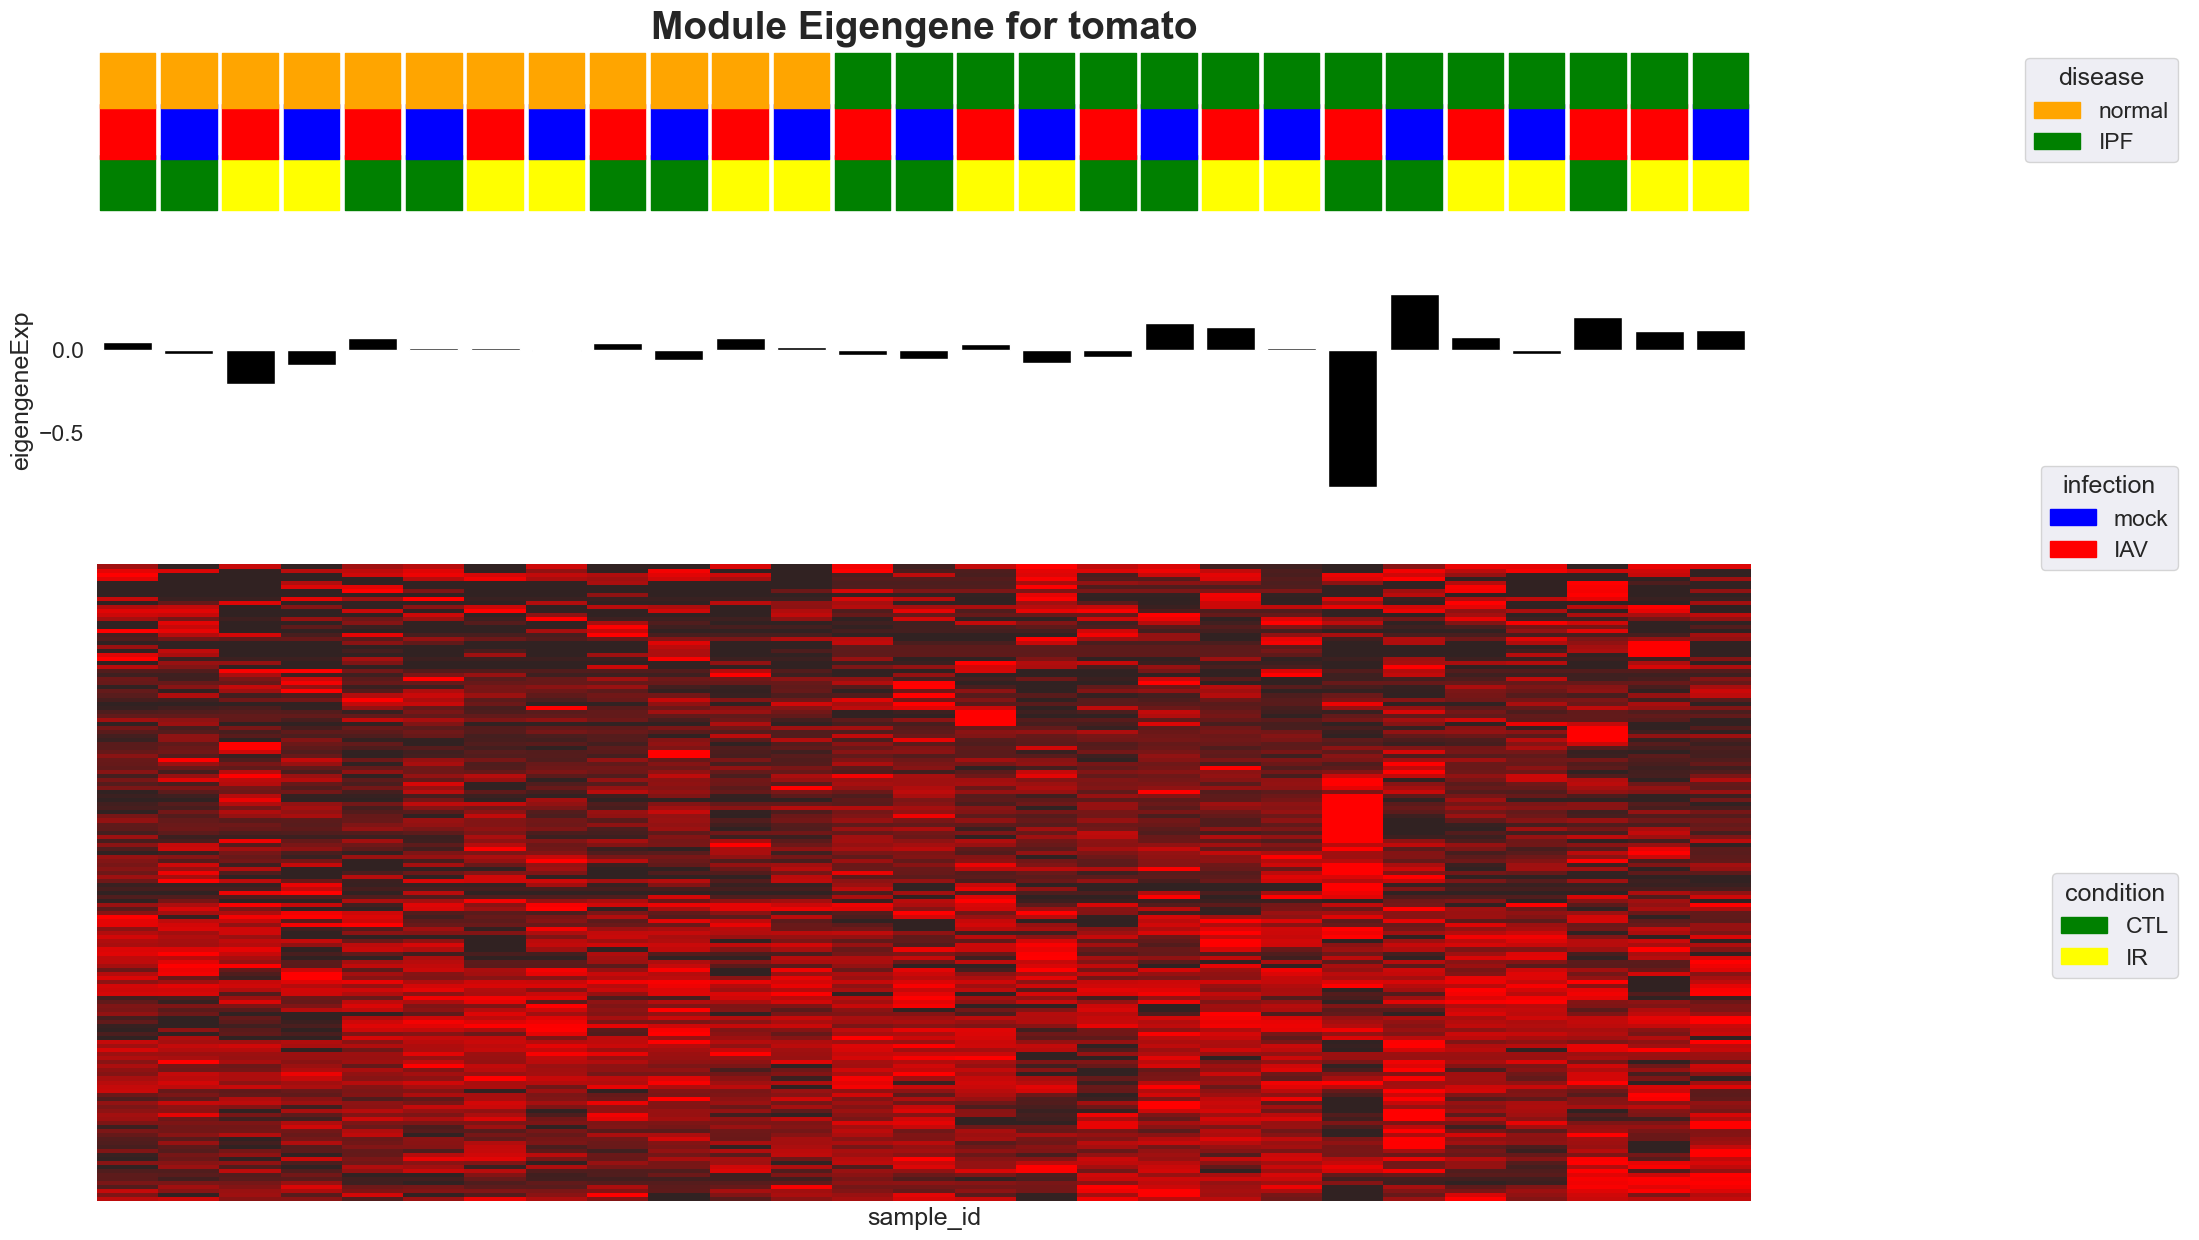

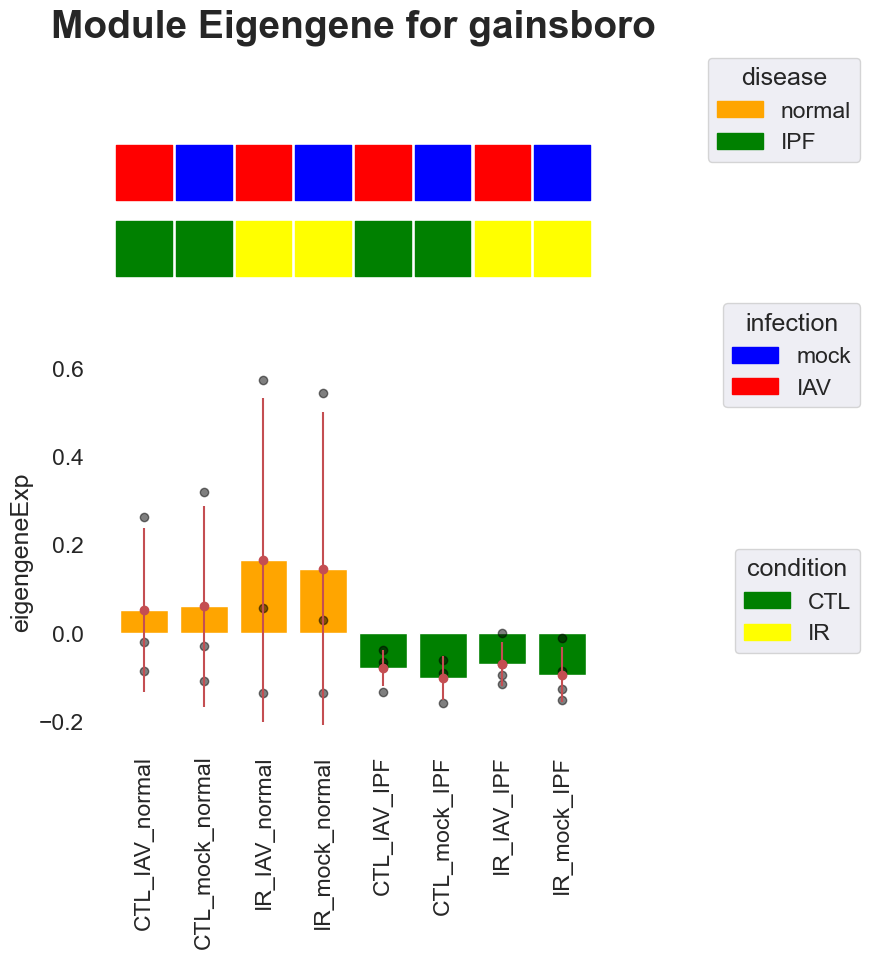

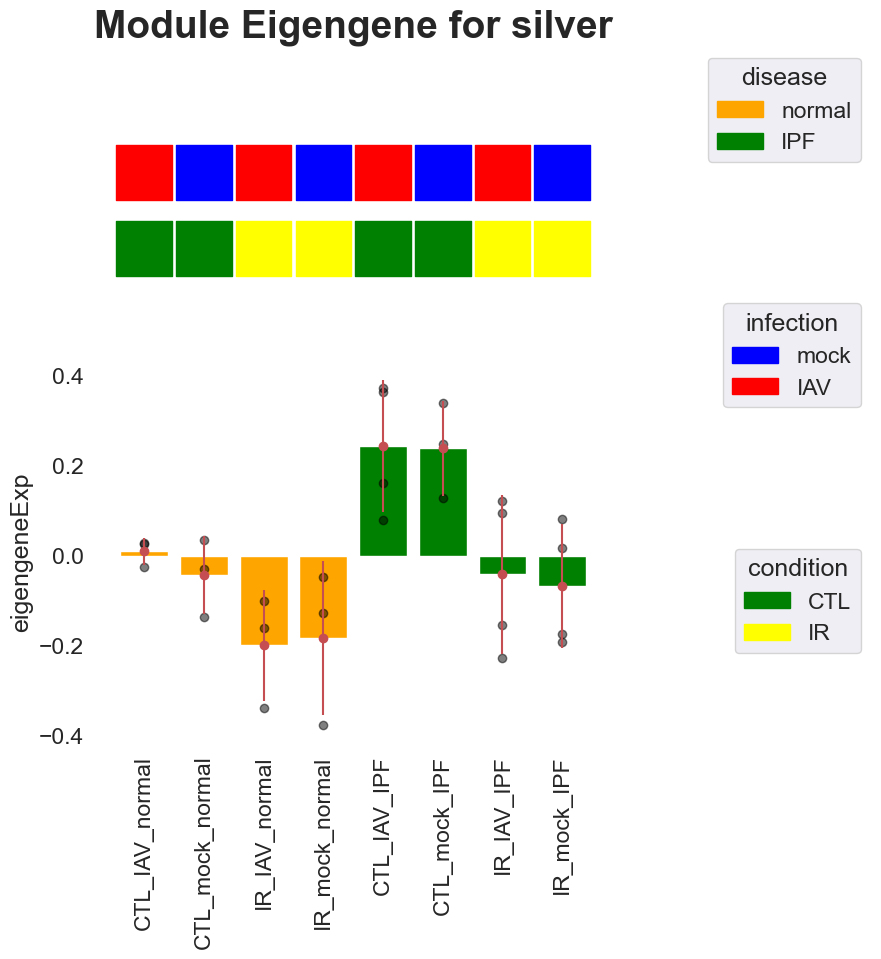

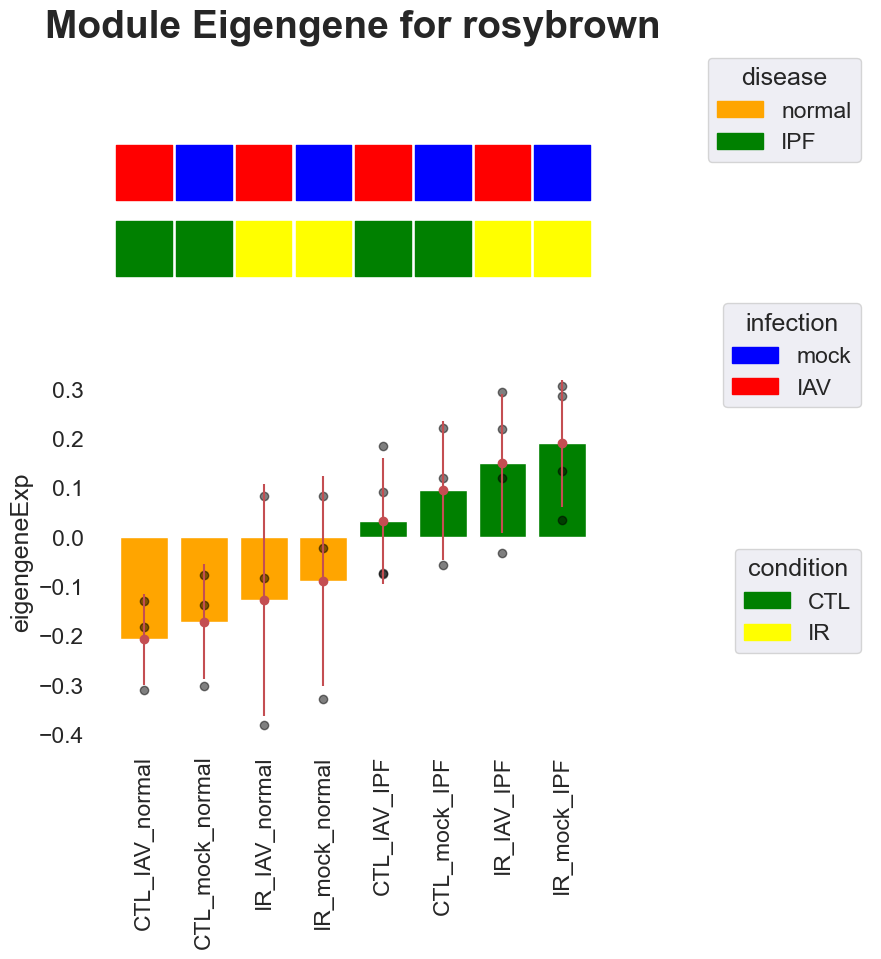

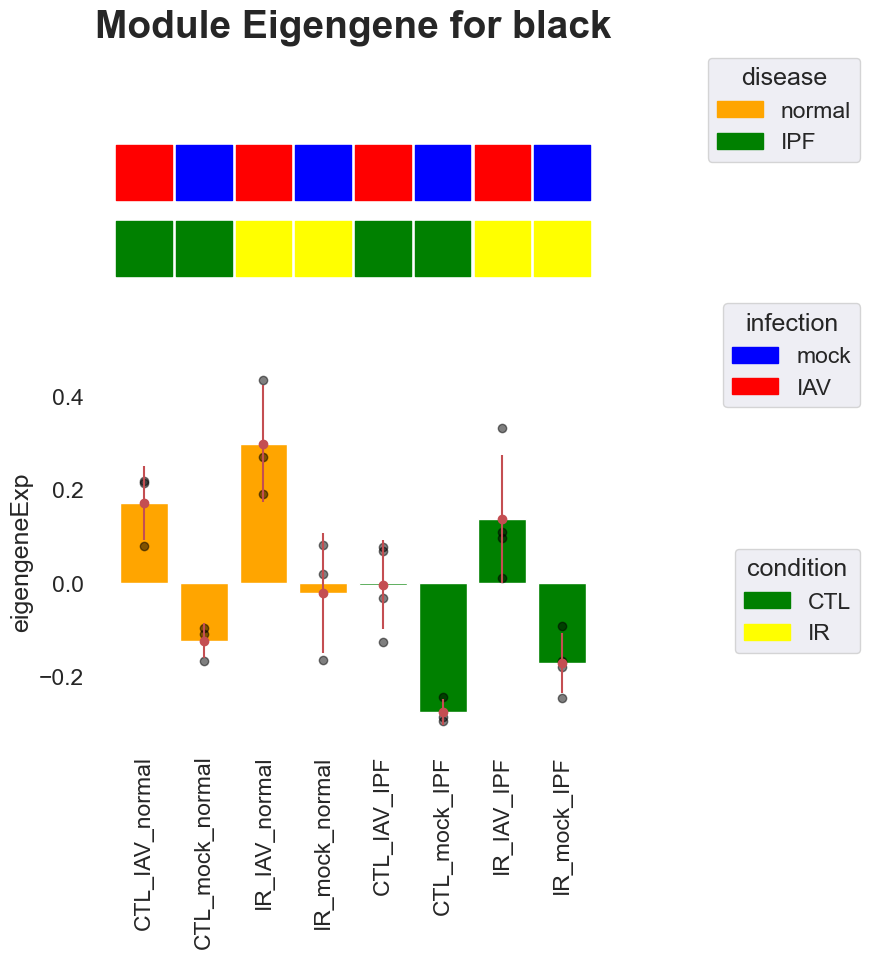

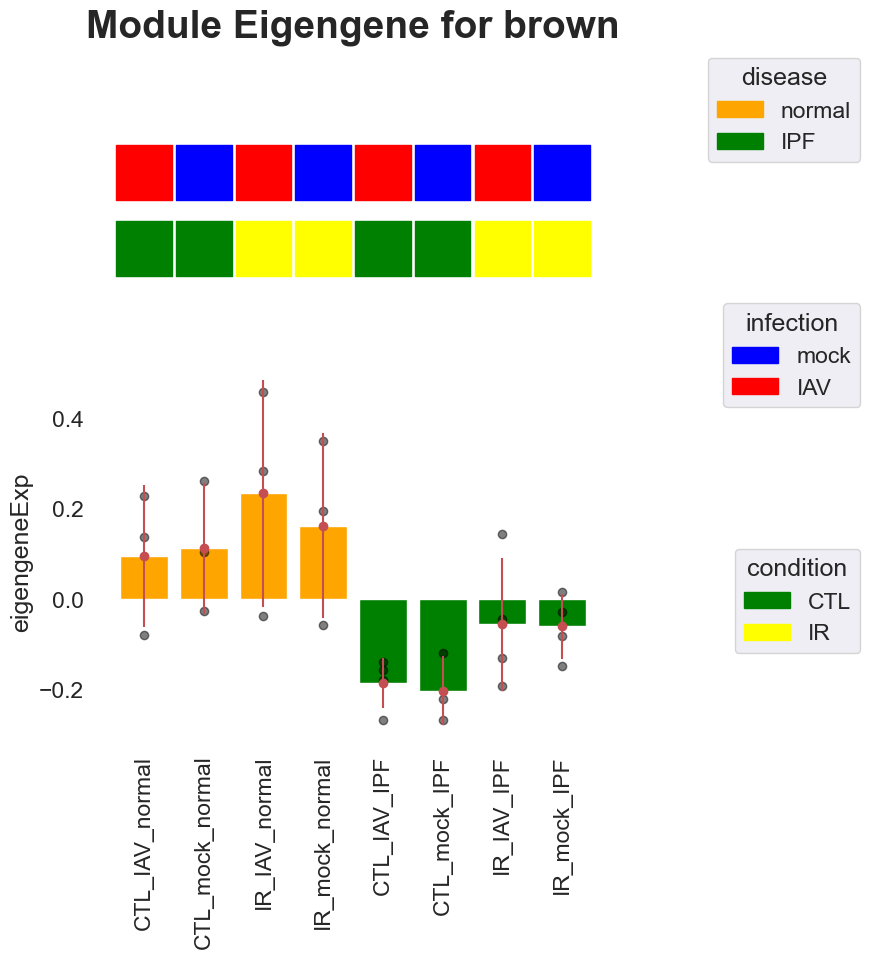

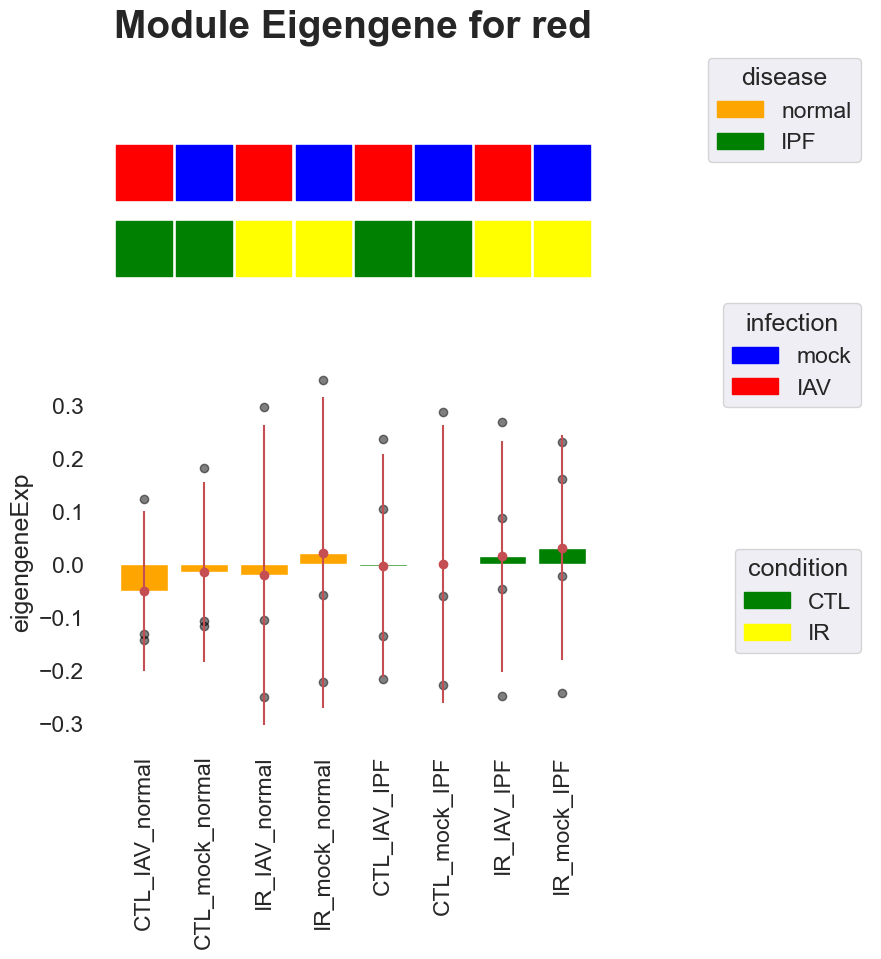

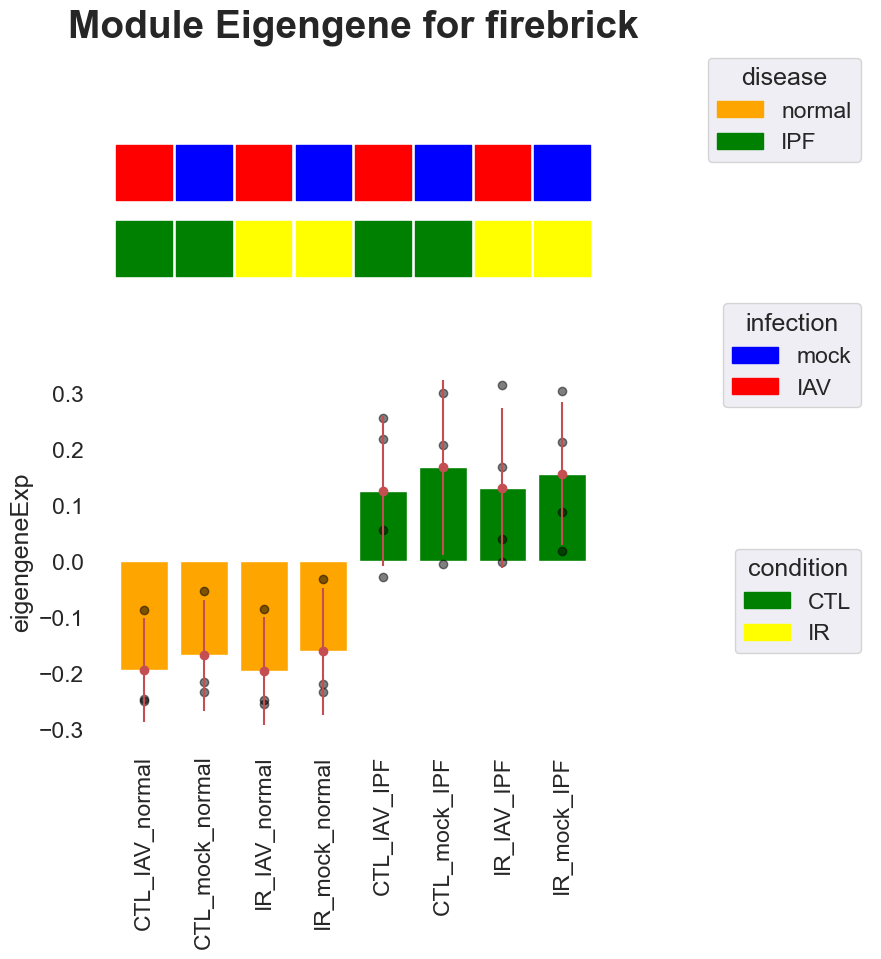

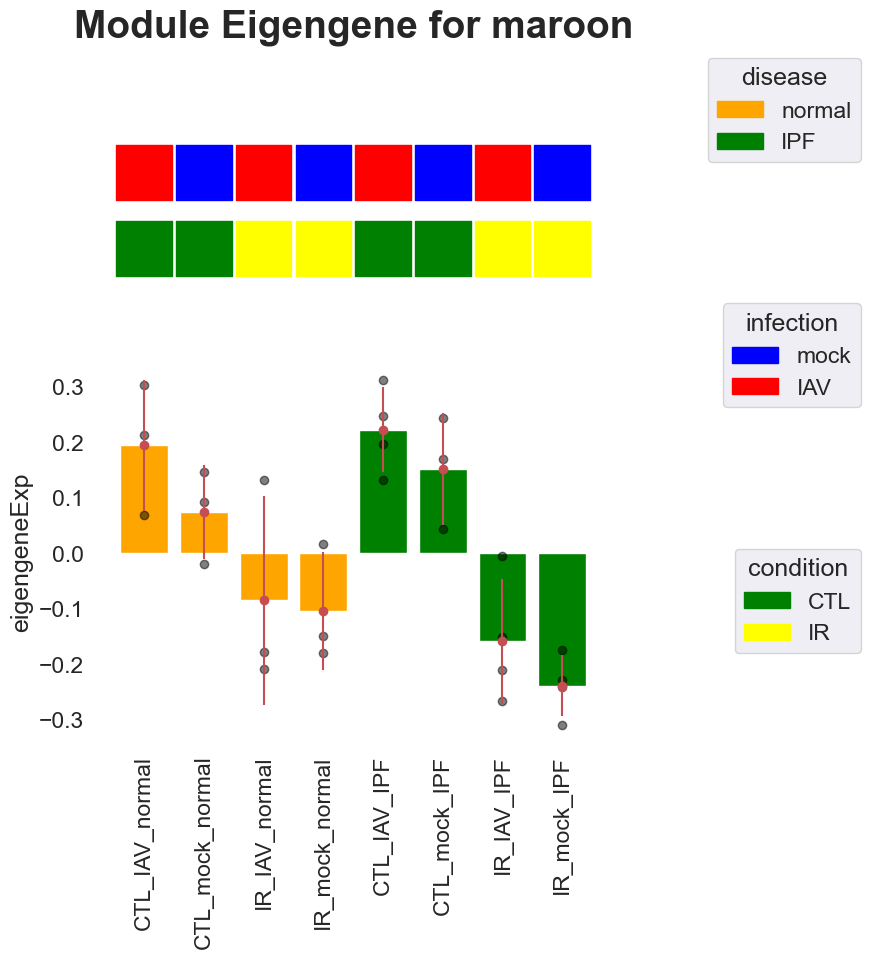

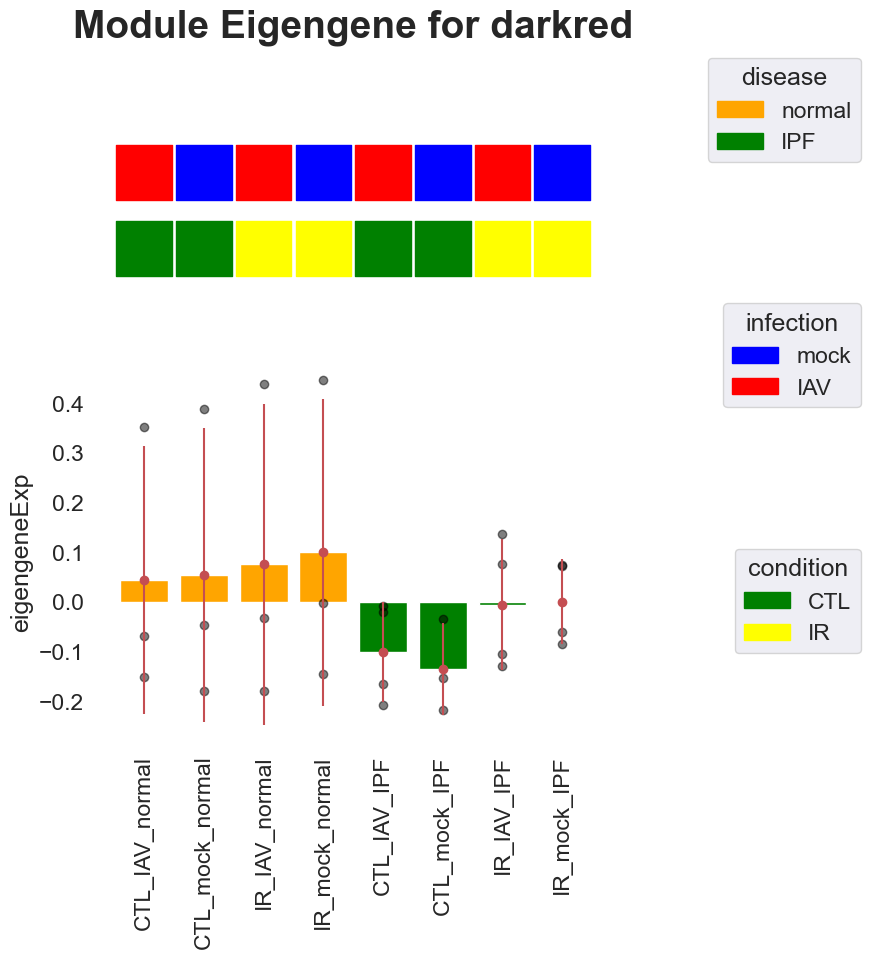

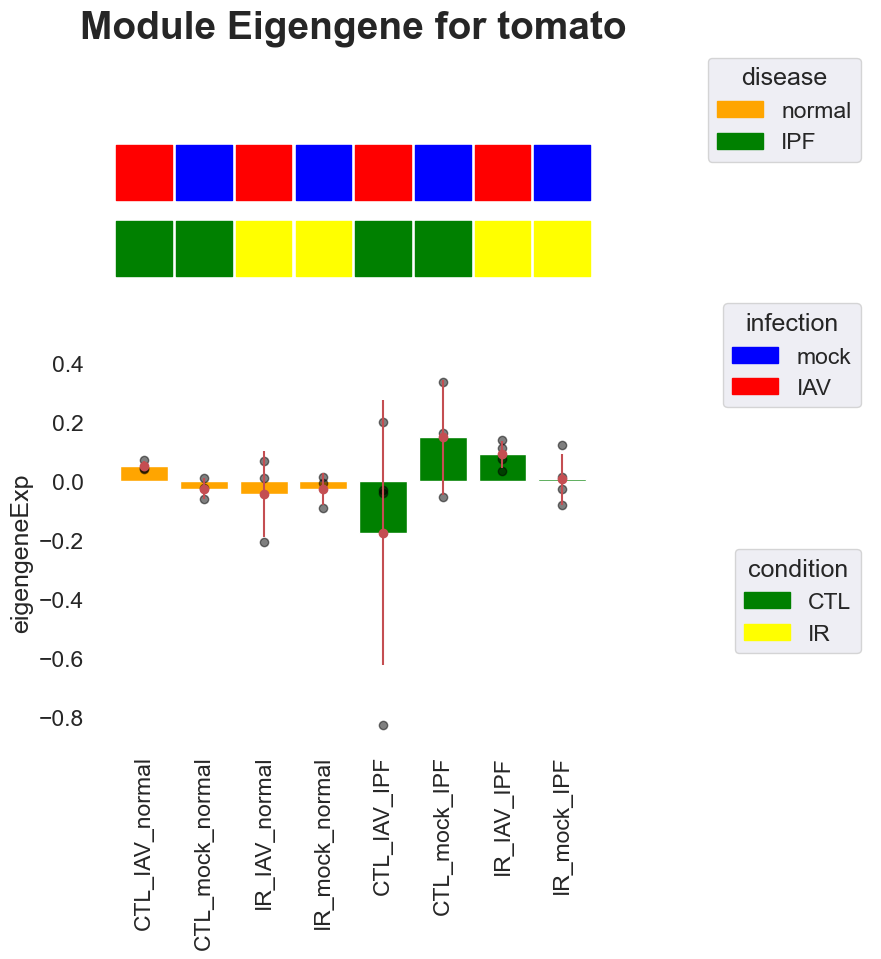

In [35]:
# Performing analysis of identified modules, including:
# Quantifying module–trait relationship
# Gene relationship to trait and modules
# Gene-ontology analysis
J080RNAseq_count_WGCNA.analyseWGCNA()

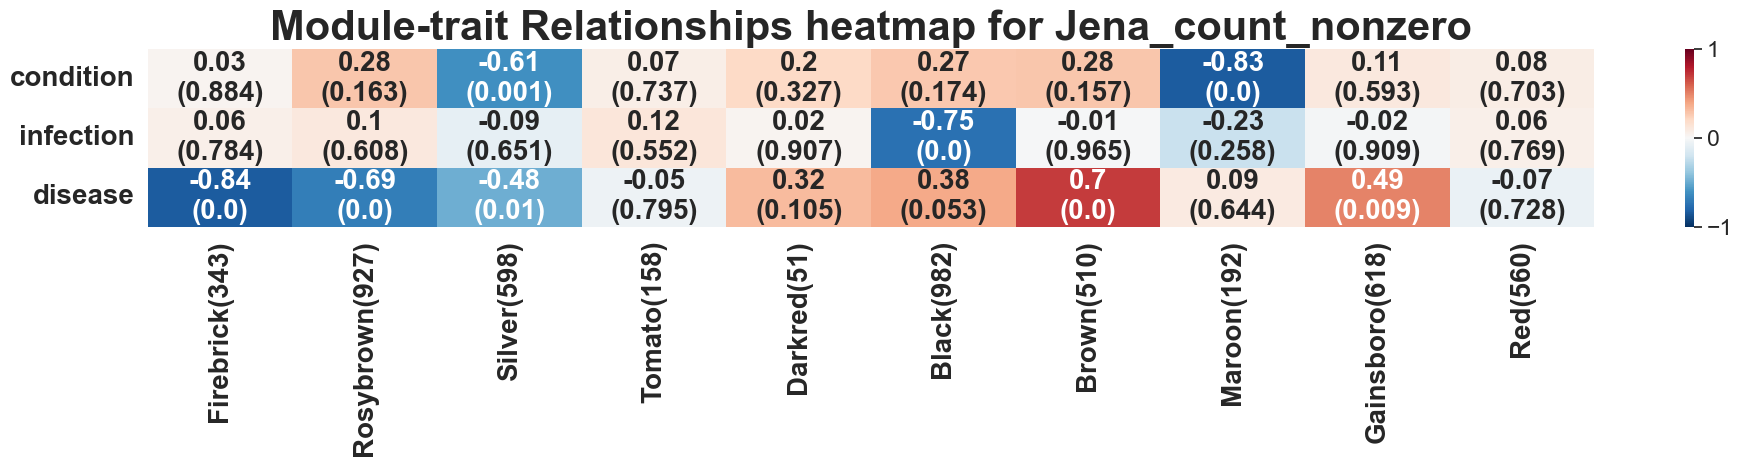

In [36]:
#better heatmap visualization
module_trait_relationships_heatmap_dual(
    J080RNAseq_count_WGCNA,
    metaData=J080RNAseq_count_WGCNA.datExpr.obs.columns.tolist(),
    figsize=(20, 5),          # try (20,5) if still tight
    show=True,
    file_name="module-traitRelationships_big"
)

In [37]:

 
# Save the WGCNA object, if you want
#J080RNAseq_count_WGCNA.saveWGCNA()

# Creating barplot and heatmap for each module with sample gene expression, since receive error for 'age' in analyzeWGCNA() above
#for mod in moduleNames:
#    J080RNAseq_count_WGCNA.plotModuleEigenGene(mod, ['sex', 'condition'], show=True)

#Converting geneIDs to common gene names for enrichment, initiating mygene database
mg = mygene.MyGeneInfo()

#Getting module names
moduleNames = J080RNAseq_count_WGCNA.datExpr.var.moduleColors.unique()
# Getting significant z-score ranked hub genes for each module
zscore_dist = 'nonnorm'
zscore_tail = 'upper'
# FS: can the gene names be added as a metadata column and this will help with GO analysis?
for mod in moduleNames:
    # Getting all (n=100000) genes and their connectivity values
    genes = J080RNAseq_count_WGCNA.top_n_hub_genes(moduleName=mod, n=100000)
    # Getting z-scores for all hub gene connectivity values and calculating p-values based on the input data distribution and desired tail(s)
    genes_zscores = robust_zscore(genes, distribution=zscore_dist, tail=zscore_tail)
    # Getting gene symbols
    genes_names = mg.querymany(genes.index.tolist() , scopes='ensembl.gene', fields='symbol', species='human')
    # Convert list of dictionaries to DataFrame
    genes_names_df = pd.DataFrame(genes_names)
    # Set index of the new DataFrame
    genes_names_df.set_index('query', inplace=True)
    # Merge hubgene ensembl ids with symbols
    genes_merge = genes.merge(genes_names_df, left_index=True, right_index=True, how='left')
    # Merge genes_merge with z-scores and p-values
    genes_merge = genes_merge.merge(genes_zscores, left_index=True, right_index=True, how='left')
    # Saving merged list of genes
    genes_merge.to_csv(J080RNAseq_count_WGCNA.outputPath+'figures/Jena_WGCNA_'+mod+'_module_genes_'+zscore_dist+'_dist_'+zscore_tail+'_pvals.csv')
    


calculating adjacency matrix ...
	Done..



618 input query terms found no hit:	['ENSG00000198535.5', 'ENSG00000170367.6', 'ENSG00000136379.13', 'ENSG00000004799.9', 'ENSG000002055


calculating adjacency matrix ...
	Done..



598 input query terms found no hit:	['ENSG00000060982.16', 'ENSG00000110880.12', 'ENSG00000081923.16', 'ENSG00000058668.17', 'ENSG000001


calculating adjacency matrix ...
	Done..



...

192 input query terms found no hit:	['ENSG00000136158.13', 'ENSG00000167553.18', 'ENSG00000123416.16', 'ENSG00000165732.15', 'ENSG000001


calculating adjacency matrix ...
	Done..



51 input query terms found no hit:	['ENSG00000187678.11', 'ENSG00000198910.15', 'ENSG00000233913.7', 'ENSG00000137033.13', 'ENSG0000029


calculating adjacency matrix ...
	Done..



158 input query terms found no hit:	['ENSG00000214940.9', 'ENSG00000144278.16', 'ENSG00000272977.1', 'ENSG00000287110.4', 'ENSG000001859


In [38]:
# convert ensembl ids to gene names, this is needed for the GO enrichment analysis. 
gene_symbols = mg.querymany(J080RNAseq_count_WGCNA.datExpr.var.index.tolist(), scopes='ensembl.gene', fields='symbol', species='human')

# filter for the gene symbol only. 
tracker = set()
idx = []
gene_name= []
for gene in gene_symbols:
    # only append the first symbol
    if gene['query'] not in tracker:
        tracker.add(gene['query'])
        idx.append(gene['query'])
        if 'symbol' in gene.keys():
            gene_name.append(gene['symbol'])
        else:
            gene_name.append(np.nan)
        
# create the gene name dataframe
gene_name_df = pd.DataFrame({"gene_name" : gene_name}, index=idx)

# add to gene symbols the wgcna object. 
J080RNAseq_count_WGCNA.datExpr.var["gene_name"] = gene_name_df

4939 input query terms found no hit:	['ENSG00000000971.18', 'ENSG00000001460.19', 'ENSG00000001461.20', 'ENSG00000001617.13', 'ENSG000000


In [39]:
import os, time
import mygene
import gseapy as gp
from gseapy.plot import dotplot
from reactome2py import analysis, content

mg = mygene.MyGeneInfo()

def strip_ensembl_version(ids):
    return [i.split(".")[0] for i in ids if isinstance(i, str) and i.startswith("ENSG")]

def ensembl_to_symbol(ensembl_ids):
    ensembl_ids = list(dict.fromkeys(strip_ensembl_version(ensembl_ids)))  # unique, no versions
    if len(ensembl_ids) == 0:
        return []
    res = mg.querymany(
        ensembl_ids,
        scopes="ensembl.gene",
        fields="symbol",
        species="human",
        as_dataframe=False
    )
    symbols = []
    for r in res:
        if isinstance(r, dict) and (not r.get("notfound")) and r.get("symbol"):
            symbols.append(str(r["symbol"]).strip())
    # unique + non-empty
    return list(dict.fromkeys([s for s in symbols if s]))

# libraries + folders
gene_set_library = [
    "GO_Biological_Process_2023", "GO_Cellular_Component_2023", "GO_Molecular_Function_2023",
    "Allen_Brain_Atlas_10x_scRNA_2021", "Allen_Brain_Atlas_up", "Allen_Brain_Atlas_down",
    "Aging_Perturbations_from_GEO_up", "Aging_Perturbations_from_GEO_down", "Chromosome_Location",
    "ENCODE_Histone_Modifications_2015", "ENCODE_TF_ChIP-seq_2015", "GTEx_Aging_Signatures_2021",
    "KEGG_2021_Human", "Panther_2016", "RNA-Seq_Disease_Gene_and_Drug_Signatures_from_GEO",
    "WikiPathway_2023_Human"
]
p_value = 0.05

go_outpath = os.path.join(J080RNAseq_count_WGCNA.outputPath, "GO")
reactome_outpath = os.path.join(J080RNAseq_count_WGCNA.outputPath, "REACTOME")
os.makedirs(go_outpath, exist_ok=True)
os.makedirs(reactome_outpath, exist_ok=True)

moduleNames = J080RNAseq_count_WGCNA.datExpr.var["moduleColors"].dropna().unique().tolist()

for mod in moduleNames:
    mask = (
        J080RNAseq_count_WGCNA.datExpr.var["moduleColors"]
        .astype(str).str.lower() == str(mod).lower()
    )

    # Ensembl IDs from var_names (this is what you actually have)
    ens_ids = J080RNAseq_count_WGCNA.datExpr.var_names[mask].tolist()

    # Convert to HGNC symbols for Enrichr/Reactome
    glist = ensembl_to_symbol(ens_ids)

    if len(glist) == 0:
        print(f"Skipping module {mod}: 0 mapped symbols (from {len(ens_ids)} Ensembl IDs)")
        continue

    print(f"{mod}: {len(glist)} symbols mapped from {len(ens_ids)} Ensembl IDs")

    # GO / Enrichr
    try:
        enr = gp.enrichr(
            gene_list=glist,
            gene_sets=gene_set_library,
            organism="human",
            outdir=None,
            cutoff=p_value
        )

        dotplot(
            enr.res2d,
            title=f"Gene ontology in {mod} module",
            cmap="viridis_r",
            cutoff=p_value,
            ofname=os.path.join(go_outpath, f"{mod}.png")
        )

    except Exception as e:
        print(f"GO enrichment issue for {mod}: {e}")

    # Reactome (use symbols; Reactome also accepts Ensembl, but symbols are fine)
    try:
        gliststr = ",".join(glist)
        result = analysis.identifiers(ids=gliststr, species="9606", p_value=str(p_value))
        token = result["summary"]["token"]

        content.export_fireworks(
            species="9606",
            ext="png",
            file=f"{mod}_fireworks_report",
            path=reactome_outpath,
            quality="10",
            title=True,
            margin="15",
            resource="Total",
            token=token
        )

    except Exception as e:
        print(f"Reactome issue for {mod}: {e}")

    time.sleep(60)  # rate limiting


1 input query terms found no hit:	['ENSG00000168078']


gainsboro: 581 symbols mapped from 618 Ensembl IDs
('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))
Reactome issue for gainsboro: cannot access local variable 'response' where it is not associated with a value
silver: 570 symbols mapped from 598 Ensembl IDs
HTTPSConnectionPool(host='reactome.org', port=443): Max retries exceeded with url: /AnalysisService/identifiers/?interactors=false&pageSize=1&page=1&sortBy=ENTITIES_FDR&order=ASC&species=9606&resource=TOTAL&pValue=0.05&includeDisease=true (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x0000018B33A31F90>, 'Connection to reactome.org timed out. (connect timeout=None)'))
Reactome issue for silver: cannot access local variable 'response' where it is not associated with a value


2 input query terms found dup hits:	[('ENSG00000301761', 2), ('ENSG00000303867', 2)]


rosybrown: 876 symbols mapped from 927 Ensembl IDs


1 input query terms found dup hits:	[('ENSG00000275496', 2)]


...

brown: 440 symbols mapped from 510 Ensembl IDs


1 input query terms found dup hits:	[('ENSG00000284116', 2)]


red: 528 symbols mapped from 560 Ensembl IDs
('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))
Reactome issue for red: cannot access local variable 'response' where it is not associated with a value
firebrick: 332 symbols mapped from 343 Ensembl IDs
HTTPSConnectionPool(host='reactome.org', port=443): Max retries exceeded with url: /ContentService/exporter/fireworks/9606.png?quality=10&flgInteractors=false&title=true&margin=15&diagramProfile=&resource=Total&coverage=false&token=MjAyNjA1MDMyMTU2MzVfNDY%253D (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x0000018B39332D50>, 'Connection to reactome.org timed out. (connect timeout=None)'))
Reactome issue for firebrick: cannot access local variable 'response' where it is not associated with a value
maroon: 179 symbols mapped from 192 Ensembl IDs
GO enrichment issue for maroon: Error sending gene list, try again later
darkred:

1 input query terms found no hit:	['ENSG00000189144']


tomato: 112 symbols mapped from 158 Ensembl IDs
GO enrichment issue for tomato: Error sending gene list, try again later


In [40]:
#storing symbols in the object
all_ens = strip_ensembl_version(J080RNAseq_count_WGCNA.datExpr.var_names.tolist())
res = mg.querymany(all_ens, scopes="ensembl.gene", fields="symbol", species="human")
ens2sym = {r["query"]: r.get("symbol") for r in res if isinstance(r, dict) and r.get("symbol")}

J080RNAseq_count_WGCNA.datExpr.var["gene_name"] = [
    ens2sym.get(g.split(".")[0], np.nan) for g in J080RNAseq_count_WGCNA.datExpr.var_names
]


5 input query terms found dup hits:	[('ENSG00000275496', 2), ('ENSG00000284116', 2), ('ENSG00000301761', 2), ('ENSG00000303867', 2), ('E
2 input query terms found no hit:	['ENSG00000168078', 'ENSG00000189144']


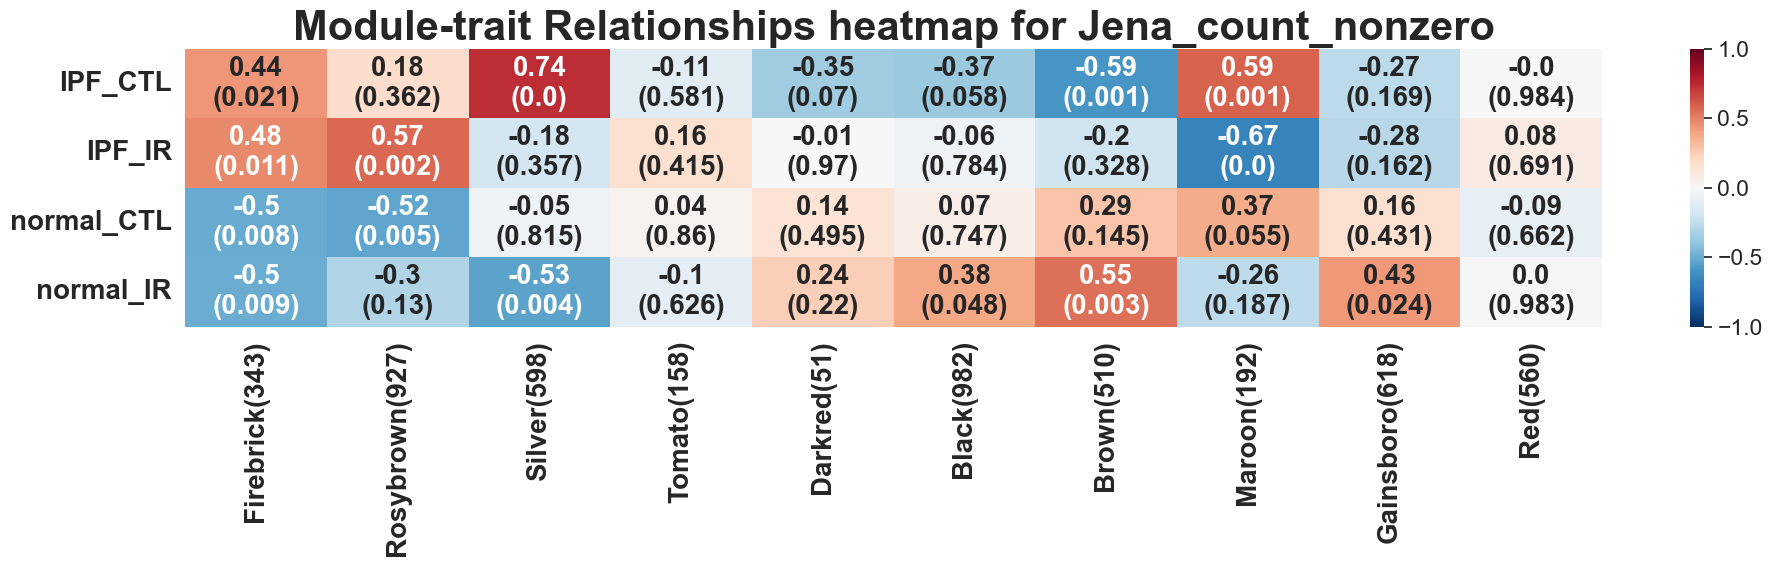

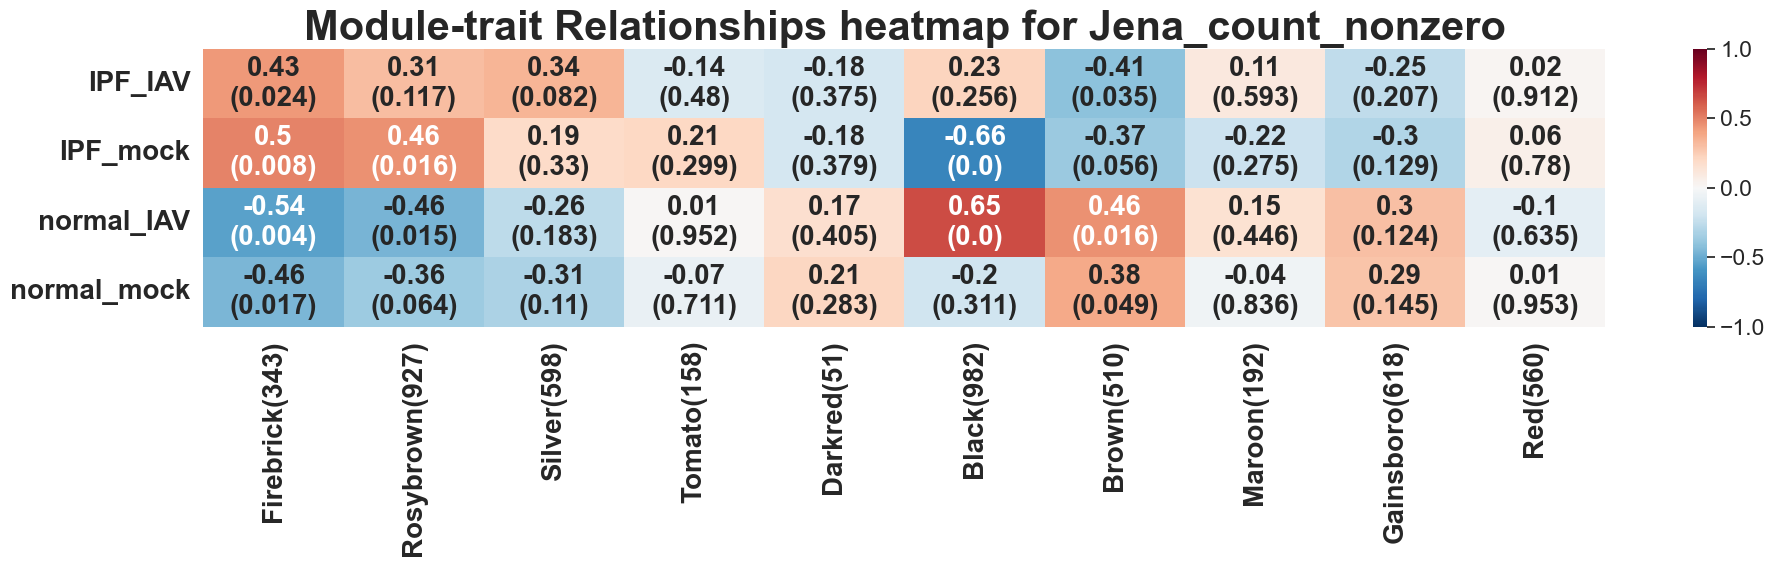

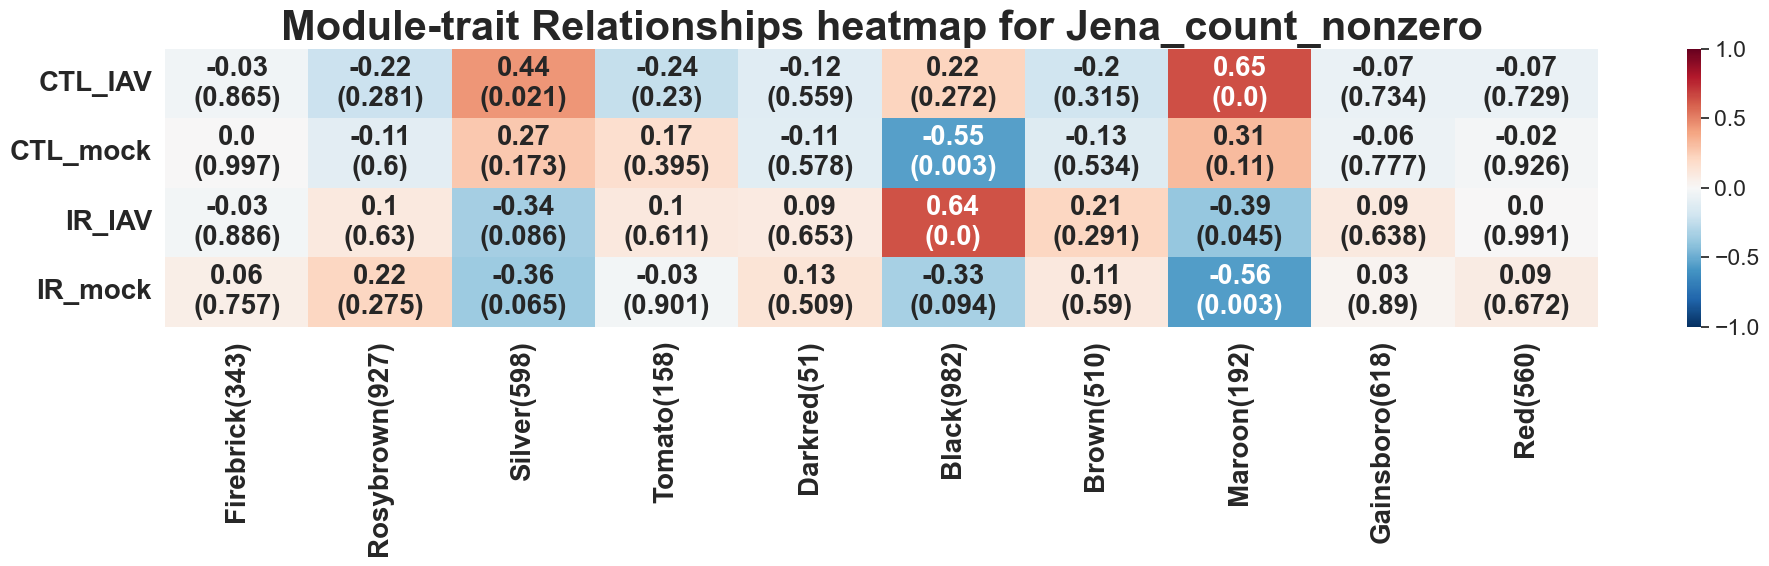

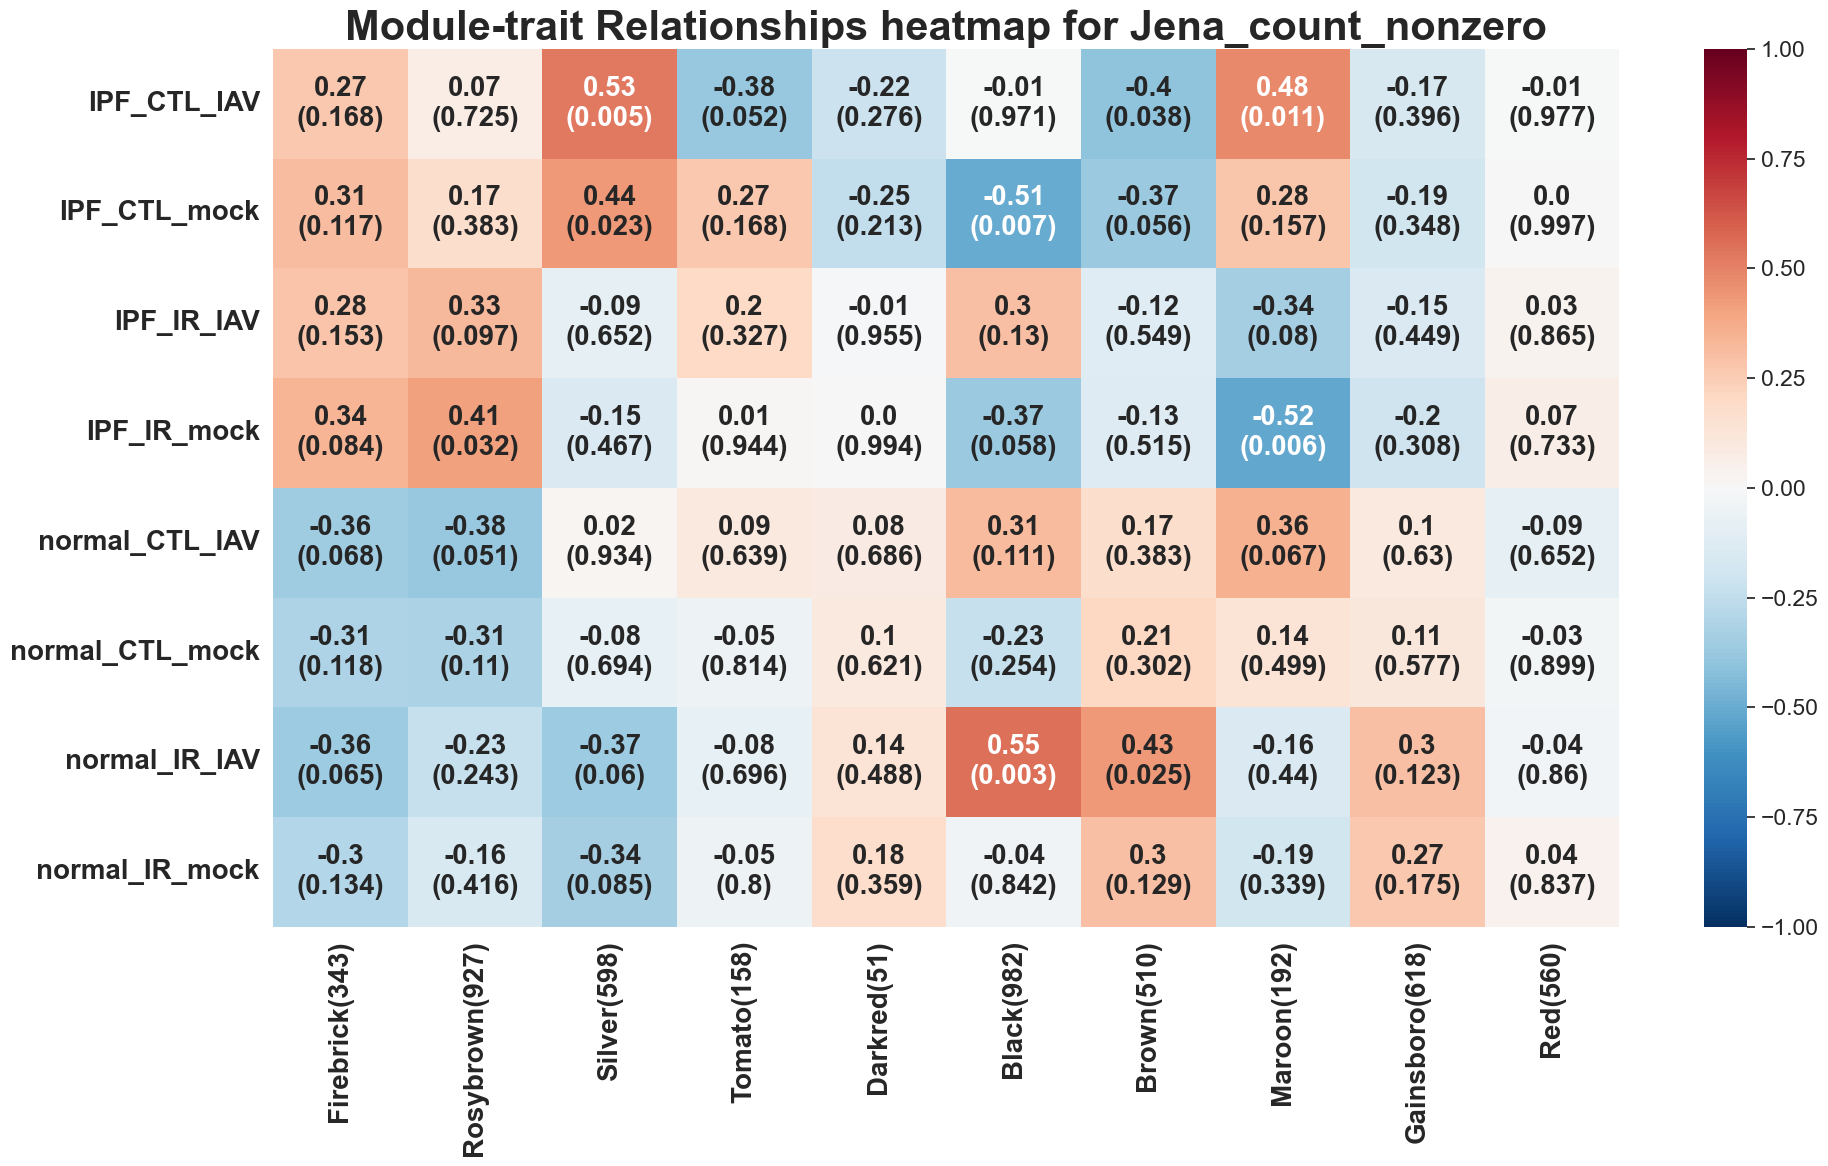

In [41]:
# Adding interaction terms to module_trait_relationships heatmap, example below
J080RNAseq_count_WGCNA.datExpr.obs['disease_condition'] = J080RNAseq_count_WGCNA.datExpr.obs['disease'] + "_"+ J080RNAseq_count_WGCNA.datExpr.obs['condition']
J080RNAseq_count_WGCNA.datExpr.obs['disease_infection'] = J080RNAseq_count_WGCNA.datExpr.obs['disease'] + "_"+ J080RNAseq_count_WGCNA.datExpr.obs['infection']
J080RNAseq_count_WGCNA.datExpr.obs['condition_infection'] = J080RNAseq_count_WGCNA.datExpr.obs['condition'] + "_"+ J080RNAseq_count_WGCNA.datExpr.obs['infection']
J080RNAseq_count_WGCNA.datExpr.obs['disease_condition_infection'] = J080RNAseq_count_WGCNA.datExpr.obs['disease'] + "_"+ J080RNAseq_count_WGCNA.datExpr.obs['condition'] + "_"+ J080RNAseq_count_WGCNA.datExpr.obs['infection']

#Saving module trait relationship heatmap including disease and condition interaction
module_trait_relationships_heatmap_dual(
    J080RNAseq_count_WGCNA,
    metaData=['disease_condition'],
    alternative='two-sided',
    file_name='module-traitRelationships-disease_condition'
)

#Saving module trait relationship heatmap including disease and infection interaction
module_trait_relationships_heatmap_dual(
    J080RNAseq_count_WGCNA,
    metaData=['disease_infection'],
    alternative='two-sided',
    file_name='module-traitRelationships-disease_infection'
)

#Saving module trait relationship heatmap including condition and infection interaction
module_trait_relationships_heatmap_dual(
    J080RNAseq_count_WGCNA,
    metaData=['condition_infection'],
    alternative='two-sided',
    file_name='module-traitRelationships-condition_infection'
)

#Saving module trait relationship heatmap for disease, condition, infection, and their interaction
module_trait_relationships_heatmap_dual(
    J080RNAseq_count_WGCNA,
    metaData=['disease_condition_infection'],
    alternative='two-sided',
    file_name='module-traitRelationships-disease_condition_infection'
)

In [42]:
print("Current outputPath:", J080RNAseq_count_WGCNA.outputPath)
print("Current figureType:", J080RNAseq_count_WGCNA.figureType)

Current outputPath: Jena_count_DEseq2_batchCorrected_nonzero_50mod_0.4thresh_robustZ_diffNames/
Current figureType: png


In [43]:
#TOM and gene attribute generation for post R script
#J080RNAseq_count_WGCNA.TOM.to_csv("TOM.csv")
#    #too big for R and csvs are read in a single thread, so it could overload my RAM
# 2) take your TOM DataFrame, push the index into a column and write Feather:
tom_df = J080RNAseq_count_WGCNA.TOM.reset_index().rename(columns={'index':'gene'})
tom_df.to_feather("TOM.feather")
J080RNAseq_count_WGCNA.datExpr.var.to_csv("gene_attributes.csv")

In [44]:
#Now performing network analysis using WGCNA object, can do single or multiple together
J080RNAseq_count_WGCNA.CoexpressionModulePlot(modules=moduleNames, numGenes=100, numConnections=500, minTOM=0, file_name="all_100genes_500conns")#["black"]
#J080RNAseq_count_WGCNA.CoexpressionModulePlot(modules=["snow"], numGenes=100, numConnections=500, minTOM=0, file_name="snow_100genes_500conns")#
#J080RNAseq_count_WGCNA.CoexpressionModulePlot(modules=["mediumspringgreen"], numGenes=100, numConnections=500, minTOM=0, file_name="mediumspringgreen_100genes_500conns")#

# Testing shinyGo api use, not working 6-8-2024
# test = shinygo_enrichment(species_code=9606, gene_list = genes, gene_set = "GO_Biological_Process_2023")


Network directory does not exist!
Creating network directory!


In [45]:
import os

# TEMPORARILY switch output to a parallel SVG folder
original_outputPath = J080RNAseq_count_WGCNA.outputPath
original_figureType = J080RNAseq_count_WGCNA.figureType

base_output_dir = original_outputPath.rstrip("/\\")
svg_output_dir = base_output_dir + "_svg" + os.sep

J080RNAseq_count_WGCNA.outputPath = svg_output_dir
J080RNAseq_count_WGCNA.figureType = "svg"

os.makedirs(
    os.path.join(J080RNAseq_count_WGCNA.outputPath, "figures"),
    exist_ok=True
)

print("Original outputPath:", original_outputPath)
print("Original figureType:", original_figureType)
print("New outputPath:", J080RNAseq_count_WGCNA.outputPath)
print("New figureType:", J080RNAseq_count_WGCNA.figureType)

Original outputPath: Jena_count_DEseq2_batchCorrected_nonzero_50mod_0.4thresh_robustZ_diffNames/
Original figureType: png
New outputPath: Jena_count_DEseq2_batchCorrected_nonzero_50mod_0.4thresh_robustZ_diffNames_svg\
New figureType: svg


In [46]:
# Restore original output settings
J080RNAseq_count_WGCNA.outputPath = original_outputPath
J080RNAseq_count_WGCNA.figureType = original_figureType

print("Restored outputPath:", J080RNAseq_count_WGCNA.outputPath)
print("Restored figureType:", J080RNAseq_count_WGCNA.figureType)

Restored outputPath: Jena_count_DEseq2_batchCorrected_nonzero_50mod_0.4thresh_robustZ_diffNames/
Restored figureType: png
